## 0. Environment Setup

In [ ]:
# Setup and imports
import sys
import json
import sqlite3
from pathlib import Path
from pprint import pprint
import glob

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

In [2]:
# Load environment and initialize Oracle
from dotenv import load_dotenv
import os

load_dotenv(project_root / '.env')

# Check available API keys
api_keys = {
    'OPENAI_API_KEY': bool(os.getenv('OPENAI_API_KEY')),
    'DEEPSEEK_API_KEY': bool(os.getenv('DEEPSEEK_API_KEY')),
    'DEEPINFRA_API_KEY': bool(os.getenv('DEEPINFRA_API_KEY')),
}
print("Available API keys:")
for k, v in api_keys.items():
    print(f"  {k}: {'✓' if v else '✗'}")

Available API keys:
  OPENAI_API_KEY: ✓
  DEEPSEEK_API_KEY: ✓
  DEEPINFRA_API_KEY: ✓


In [ ]:
# Initialize LLM Oracle
from src.llm_oracle import Oracle

# Choose model based on available keys
if os.getenv('DEEPSEEK_API_KEY'):
    MODEL = "deepseek-chat"
    API_KEY = os.getenv('DEEPSEEK_API_KEY')
elif os.getenv('OPENAI_API_KEY'):
    MODEL = "gpt-4o-mini"
    API_KEY = os.getenv('OPENAI_API_KEY')
else:
    raise ValueError("No API key available!")

oracle = Oracle(model=MODEL, apikey=API_KEY)
print(f"Using model: {MODEL}")

## 1. Database Validation and Schema Inspection

Spider databases may not all have `schema.sql` files. We need to validate and filter.

In [ ]:
# Define paths
SPIDER_ROOT = project_root / 'data' / 'spider'
SPIDER_DB_DIR = SPIDER_ROOT / 'database'
SPIDER_TEST_DB_DIR = SPIDER_ROOT / 'test_database'
SPIDER_DEV_DATA = SPIDER_ROOT / 'dev.json'
SPIDER_TRAIN_DATA = SPIDER_ROOT / 'train_spider.json'  # ← TRAIN DATA
SPIDER_TEST_DATA = SPIDER_ROOT / 'test.json'

print(f"Spider root: {SPIDER_ROOT}")
print(f"Database dir: {SPIDER_DB_DIR}")
print(f"Test database dir: {SPIDER_TEST_DB_DIR}")
print(f"\nPaths exist:")
print(f"  Spider root: {SPIDER_ROOT.exists()}")
print(f"  Database dir: {SPIDER_DB_DIR.exists()}")
print(f"  Dev data: {SPIDER_DEV_DATA.exists()}")
print(f"  Train data: {SPIDER_TRAIN_DATA.exists()}")  # ← CHECK TRAIN
print(f"  Test data: {SPIDER_TEST_DATA.exists()}")

In [5]:
# Utility functions for database validation and policy analysis
# Import shared policy utility functions
from src.role_evaluator.quality_metrics import RoleQualityEvaluator

# Convenience aliases for the static methods
count_policy_columns = RoleQualityEvaluator.count_policy_columns
has_wildcard_policy = RoleQualityEvaluator.has_wildcard_policy

def validate_spider_databases(db_root: Path) -> dict:
    """Validate all databases in a directory."""
    results = {
        'valid': [],
        'missing_schema': [],
        'missing_sqlite': [],
        'total': 0
    }
    
    for db_dir in sorted(db_root.iterdir()):
        if not db_dir.is_dir() or db_dir.name.startswith('.'):
            continue
        
        results['total'] += 1
        db_name = db_dir.name
        
        has_schema = (db_dir / 'schema.sql').exists()
        has_sqlite = any(db_dir.glob('*.sqlite'))
        
        if has_schema and has_sqlite:
            results['valid'].append(db_name)
        elif not has_schema:
            results['missing_schema'].append(db_name)
        elif not has_sqlite:
            results['missing_sqlite'].append(db_name)
    
    return results

# Validate dev databases
dev_validation = validate_spider_databases(SPIDER_DB_DIR)
print("=== Dev Database Validation ===")
print(f"Total: {dev_validation['total']}")
print(f"Valid: {len(dev_validation['valid'])}")
print(f"Missing schema.sql: {len(dev_validation['missing_schema'])}")
print(f"Missing .sqlite: {len(dev_validation['missing_sqlite'])}")

if dev_validation['missing_schema']:
    print(f"\nDatabases without schema.sql (first 10):")
    for db in dev_validation['missing_schema'][:10]:
        print(f"  - {db}")
    if len(dev_validation['missing_schema']) > 10:
        print(f"  ... and {len(dev_validation['missing_schema']) - 10} more")

=== Dev Database Validation ===
Total: 166
Valid: 148
Missing schema.sql: 18
Missing .sqlite: 0

Databases without schema.sql (first 10):
  - car_1
  - chinook_1
  - college_1
  - college_2
  - company_1
  - epinions_1
  - flight_2
  - flight_4
  - formula_1
  - icfp_1
  ... and 8 more


In [6]:
# Helper functions for schema extraction
from src.processors.spider_column_level_rbac_generator import parse_schema_sql, get_schema_from_db

def get_schema_from_sqlite(db_path: str) -> dict:
    """Extract detailed schema from SQLite database."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    tables = [row[0] for row in cursor.fetchall()]
    
    schema = {}
    for table in tables:
        cursor.execute(f"PRAGMA table_info(`{table}`)")
        columns = cursor.fetchall()
        
        cursor.execute(f"PRAGMA foreign_key_list(`{table}`)")
        fks = {row[3]: f"{row[2]}.{row[4]}" for row in cursor.fetchall()}
        
        schema[table] = {
            'columns': [
                {
                    'name': col[1],
                    'type': col[2] or 'TEXT',
                    'pk': col[5] == 1,
                    'not_null': col[3] == 1,
                    'fk': fks.get(col[1])
                }
                for col in columns
            ]
        }
    
    conn.close()
    return schema

def format_schema_for_prompt(schema: dict, db_name: str) -> str:
    """Format schema as text for LLM prompt."""
    lines = [f"Database: {db_name}\n"]
    
    for table, info in schema.items():
        lines.append(f"Table: {table}")
        lines.append("Columns:")
        for col in info['columns']:
            constraints = []
            if col['pk']:
                constraints.append("PRIMARY KEY")
            if col['not_null'] and not col['pk']:
                constraints.append("NOT NULL")
            if col['fk']:
                constraints.append(f"FK -> {col['fk']}")
            
            constraint_str = f" [{', '.join(constraints)}]" if constraints else ""
            lines.append(f"  - {col['name']} ({col['type']}){constraint_str}")
        lines.append("")
    
    return "\n".join(lines)

print("✓ Schema helper functions loaded")

✓ Schema helper functions loaded


In [ ]:
# Inspect a sample database
TEST_DB = "concert_singer"  # A common, well-structured Spider database
db_path = SPIDER_DB_DIR / TEST_DB / f"{TEST_DB}.sqlite"

print(f"Loading schema from: {db_path}")
schema = get_schema_from_sqlite(str(db_path))

print(f"\nTables: {list(schema.keys())}")
for table, info in schema.items():
    print(f"\n{table}: {len(info['columns'])} columns")
    for col in info['columns']:
        print(f"  - {col['name']} ({col['type']})")

In [8]:
# Format schema for prompt
schema_text = format_schema_for_prompt(schema, TEST_DB)
print(schema_text)

Database: concert_singer

Table: stadium
Columns:
  - Stadium_ID (INT) [PRIMARY KEY]
  - Location (TEXT)
  - Name (TEXT)
  - Capacity (INT)
  - Highest (INT)
  - Lowest (INT)
  - Average (INT)

Table: singer
Columns:
  - Singer_ID (INT) [PRIMARY KEY]
  - Name (TEXT)
  - Country (TEXT)
  - Song_Name (TEXT)
  - Song_release_year (TEXT)
  - Age (INT)
  - Is_male (bool)

Table: concert
Columns:
  - concert_ID (INT) [PRIMARY KEY]
  - concert_Name (TEXT)
  - Theme (TEXT)
  - Stadium_ID (TEXT) [FK -> stadium.Stadium_ID]
  - Year (TEXT)

Table: singer_in_concert
Columns:
  - concert_ID (INT) [PRIMARY KEY, FK -> concert.concert_ID]
  - Singer_ID (TEXT) [FK -> singer.Singer_ID]



## 2. Load Prompts for Column-Level Role Generation

Reuse the same prompts as Bird (column_level_prompts.py).

In [9]:
# Reload modules to get latest changes
import importlib
import configs.column_level_prompts
import src.role_parser.column_level_parser
importlib.reload(configs.column_level_prompts)
importlib.reload(src.role_parser.column_level_parser)

# Import prompts and parser
from configs.column_level_prompts import (
    COLUMN_LEVEL_SYSTEM_PROMPT, 
    COLUMN_LEVEL_USER_PROMPT_TEMPLATE,
    DEFAULT_MAX_TOKENS
)
from src.role_parser import parse_column_level_roles, validate_roles_against_schema

print("✓ Loaded from external modules:")
print(f"  - COLUMN_LEVEL_SYSTEM_PROMPT ({len(COLUMN_LEVEL_SYSTEM_PROMPT)} chars)")
print(f"  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE")
print(f"  - DEFAULT_MAX_TOKENS = {DEFAULT_MAX_TOKENS}")
print(f"  - parse_column_level_roles (auto-detects JSON/Text)")
print(f"  - validate_roles_against_schema")

print("\n--- System Prompt Preview ---")
print(COLUMN_LEVEL_SYSTEM_PROMPT[:500])
print("...")

✓ Loaded from external modules:
  - COLUMN_LEVEL_SYSTEM_PROMPT (2734 chars)
  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE
  - DEFAULT_MAX_TOKENS = 4000
  - parse_column_level_roles (auto-detects JSON/Text)
  - validate_roles_against_schema

--- System Prompt Preview ---
You are a database security expert specializing in fine-grained Role-Based Access Control (RBAC).
Your job is to read a relational database schema and propose a COHERENT set of roles with COLUMN-LEVEL permissions.

Key goals:
- Minimize role count while covering real-world workflows (decide number of roles according to real world scenario).
- Each role must be clearly related to others (same scenario, complementary duties).
- Enforce least-privilege at the COLUMN level (specify which columns eac
...


## 3. Batch Generate Column-Level Roles for Spider

Generate column-level role assignments for all valid Spider databases.

In [12]:
# Analyze Spider Dev dataset structure
# Understand which databases are actually used by dev.json

from collections import Counter

# Load dev data
with open(SPIDER_DEV_DATA) as f:
    spider_dev_data = json.load(f)

# Count queries per database in dev set
dev_db_counts = Counter(item['db_id'] for item in spider_dev_data)
dev_dbs = set(dev_db_counts.keys())

print("=" * 60)
print("Spider Dev Dataset Structure Analysis")
print("=" * 60)
print()
print(f"Total queries in dev.json: {len(spider_dev_data)}")
print(f"Databases involved: {len(dev_dbs)} (not all {dev_validation['total']} in database/)")
print()
print("Queries per database:")
for db, count in dev_db_counts.most_common():
    has_schema = (SPIDER_DB_DIR / db / 'schema.sql').exists()
    status = "has schema.sql" if has_schema else "SQLite fallback"
    print(f"  {db}: {count} queries [{status}]")

# Check how many dev databases are missing schema.sql
dev_missing_schema = [db for db in dev_dbs if not (SPIDER_DB_DIR / db / 'schema.sql').exists()]
dev_with_schema = [db for db in dev_dbs if (SPIDER_DB_DIR / db / 'schema.sql').exists()]

print()
print("=" * 60)
print("Summary: Generate roles for 20 databases used in dev.json")
print("=" * 60)
print(f"  With schema.sql: {len(dev_with_schema)}")
print(f"  Need SQLite fallback: {len(dev_missing_schema)}")
if dev_missing_schema:
    print(f"  Fallback databases: {dev_missing_schema}")

Spider Dev Dataset Structure Analysis

Total queries in dev.json: 1034
Databases involved: 20 (not all 166 in database/)

Queries per database:
  world_1: 120 queries [SQLite fallback]
  car_1: 92 queries [SQLite fallback]
  cre_Doc_Template_Mgt: 84 queries [has schema.sql]
  dog_kennels: 82 queries [has schema.sql]
  flight_2: 80 queries [SQLite fallback]
  student_transcripts_tracking: 78 queries [has schema.sql]
  wta_1: 62 queries [SQLite fallback]
  tvshow: 62 queries [has schema.sql]
  network_1: 56 queries [has schema.sql]
  concert_singer: 45 queries [has schema.sql]
  pets_1: 42 queries [has schema.sql]
  poker_player: 40 queries [has schema.sql]
  orchestra: 40 queries [has schema.sql]
  employee_hire_evaluation: 38 queries [has schema.sql]
  course_teach: 30 queries [has schema.sql]
  singer: 30 queries [has schema.sql]
  museum_visit: 18 queries [has schema.sql]
  battle_death: 16 queries [has schema.sql]
  voter_1: 15 queries [SQLite fallback]
  real_estate_properties: 4 q

In [ ]:
# Batch processing configuration
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Configuration
WORKERS = 40
SAMPLES = 0  # 0 for all databases
MAX_TOKENS = DEFAULT_MAX_TOKENS

# Target only databases used in dev.json (20 databases, not all 166)
# dev_dbs comes from Cell 14's analysis
target_dbs = sorted(list(dev_dbs))
if SAMPLES > 0:
    target_dbs = target_dbs[:SAMPLES]

print(f"Configuration:")
print(f"  Workers: {WORKERS}")
print(f"  Target databases (from dev.json): {len(target_dbs)}")
print(f"  Max tokens: {MAX_TOKENS}")
print(f"  Model: {MODEL}")
print(f"\nDatabases to process:")
for db in target_dbs:
    has_schema = (SPIDER_DB_DIR / db / 'schema.sql').exists()
    status = "schema.sql" if has_schema else "SQLite fallback"
    print(f"  - {db} [{status}]")

In [6]:
# Understand which databases are actually used by train.json - MODIFIED FOR TRAIN
import json
from collections import Counter

# Load TRAIN data instead of dev
with open(SPIDER_TRAIN_DATA) as f:
    spider_train_data = json.load(f)

# Count queries per database in TRAIN set
train_db_counts = Counter(item['db_id'] for item in spider_train_data)

# Identify which validated databases are actually used
valid_db_set = set(dev_validation['valid'])
used_dbs = set(train_db_counts.keys())
target_dbs = valid_db_set & used_dbs

print("=== Database Coverage (TRAIN) ===")
print(f"Total queries in train.json: {len(spider_train_data)}")
print(f"Unique databases in train.json: {len(used_dbs)}")
print(f"Valid databases (with schema.sql): {len(valid_db_set)}")
print(f"Target databases (valid & used in train): {len(target_dbs)}")

# Show top databases by query count in TRAIN set
print(f"\nTop 10 databases by query count (TRAIN):")
for db, count in train_db_counts.most_common(10):
    status = "✓" if db in target_dbs else "✗"
    print(f"  {status} {db}: {count} queries")

if len(target_dbs) < len(used_dbs):
    missing_schemas = used_dbs - valid_db_set
    print(f"\n⚠️ {len(missing_schemas)} databases in train.json lack schema.sql:")
    for db in sorted(missing_schemas):
        print(f"  - {db}")

print(f"\nSummary: Generate roles for {len(target_dbs)} databases used in train.json")

=== Database Coverage (TRAIN) ===
Total queries in train.json: 7000
Unique databases in train.json: 140
Valid databases (with schema.sql): 148
Target databases (valid & used in train): 127

Top 10 databases by query count (TRAIN):
  ✗ college_2: 170 queries
  ✗ college_1: 164 queries
  ✓ hr_1: 124 queries
  ✓ store_1: 112 queries
  ✓ soccer_2: 106 queries
  ✓ bike_1: 104 queries
  ✓ music_1: 100 queries
  ✓ hospital_1: 100 queries
  ✓ music_2: 100 queries
  ✓ dorm_1: 100 queries

⚠️ 13 databases in train.json lack schema.sql:
  - chinook_1
  - college_1
  - college_2
  - company_1
  - epinions_1
  - flight_4
  - formula_1
  - icfp_1
  - inn_1
  - small_bank_1
  - student_1
  - twitter_1
  - wine_1

Summary: Generate roles for 127 databases used in train.json


In [9]:
# Generate column-level role assignments for TRAIN databases using LLM
# This cell generates roles for 127 databases in train.json

from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm  # Use standard tqdm instead of notebook version
import sqlite3
import json
import re

from configs.column_level_prompts import (
    COLUMN_LEVEL_SYSTEM_PROMPT, 
    COLUMN_LEVEL_USER_PROMPT_TEMPLATE,
    DEFAULT_MAX_TOKENS
)

# ============================================================
# Helper functions
# ============================================================

def get_schema_from_sqlite(db_path: str) -> dict:
    """Extract schema from SQLite database."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    schema = {}
    
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    tables = [row[0] for row in cursor.fetchall()]
    
    for table in tables:
        cursor.execute(f"PRAGMA table_info(\"{table}\")")
        columns = []
        for row in cursor.fetchall():
            col_info = {
                'name': row[1],
                'type': row[2] or 'TEXT',
                'notnull': bool(row[3]),
                'pk': bool(row[5])
            }
            columns.append(col_info)
        
        cursor.execute(f"PRAGMA foreign_key_list(\"{table}\")")
        fks = {}
        for fk in cursor.fetchall():
            fks[fk[3]] = f"{fk[2]}.{fk[4]}"
        
        for col in columns:
            if col['name'] in fks:
                col['fk'] = fks[col['name']]
        
        schema[table] = {'columns': columns}
    
    conn.close()
    return schema

def format_schema_for_prompt(schema: dict, db_name: str) -> str:
    """Format schema dict to text for LLM prompt."""
    lines = [f"Database: {db_name}\n"]
    for table, info in schema.items():
        lines.append(f"Table: {table}")
        for col in info['columns']:
            pk_marker = " [PK]" if col.get('pk') else ""
            fk_marker = f" -> {col['fk']}" if col.get('fk') else ""
            lines.append(f"  - {col['name']} ({col['type']}){pk_marker}{fk_marker}")
        lines.append("")
    return "\n".join(lines)

def parse_column_level_roles(llm_response: str) -> list:
    """Parse LLM response to extract role assignments."""
    json_match = re.search(r'\[[\s\S]*\]', llm_response)
    if json_match:
        try:
            return json.loads(json_match.group())
        except json.JSONDecodeError:
            pass
    return []

def generate_single_db_roles(db_name: str, db_root: str) -> dict:
    """Generate roles for a single database."""
    db_path = Path(db_root) / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": "Database not found"}
    
    try:
        schema = get_schema_from_sqlite(str(db_path))
        schema_text = format_schema_for_prompt(schema, db_name)
        
        response = oracle.query(
            prompt_sys=COLUMN_LEVEL_SYSTEM_PROMPT,
            prompt_user=COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=schema_text),
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=DEFAULT_MAX_TOKENS
        )
        
        roles = parse_column_level_roles(response['answer'])
        usage = response.get('usage', {})
        
        if not roles:
            return {
                "database": db_name, 
                "status": "parse_error",
                "error": "Failed to parse roles",
                "raw": response['answer'][:200]
            }
        
        # Convert to standard format
        assignments = [
            {
                "role": r["role"],
                "description": r.get("description", ""),
                "policy": r.get("columns", {})
            }
            for r in roles
        ]
        
        return {
            "database": db_name,
            "status": "success",
            "roles": len(assignments),
            "assignments": assignments,
            "tokens": usage.get('total_tokens', 0)
        }
        
    except Exception as e:
        return {"database": db_name, "status": "error", "error": str(e)}

# ============================================================
# Main: Generate roles for all 127 TRAIN databases
# ============================================================

today = datetime.now().strftime("%Y%m%d")
target_databases = sorted(target_dbs)
WORKERS = 40  # Parallel workers

print(f"=== Generate Column-Level Roles for TRAIN ===")
print(f"  Target databases: {len(target_databases)}")
print(f"  Workers: {WORKERS}")
print(f"  Model: {MODEL}")
print(f"  Output: column_level_role_assignments_spider_train_{today}.json")
print()

# Generate in parallel
results = {"assignments": {}, "metadata": {"model": MODEL, "timestamp": today, "total_databases": 0}}
success_count = 0
fail_count = 0

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {
        executor.submit(generate_single_db_roles, db, str(SPIDER_DB_DIR)): db 
        for db in target_databases
    }
    
    for future in tqdm(as_completed(futures), total=len(futures), desc="Generating roles"):
        db_name = futures[future]
        result = future.result()
        
        if result["status"] == "success":
            results["assignments"][db_name] = result["assignments"]
            success_count += 1
        else:
            fail_count += 1
            print(f"\n  ✗ {db_name}: {result.get('error', 'unknown')}")

results["metadata"]["total_databases"] = len(results["assignments"])
results["metadata"]["total_roles"] = sum(len(r) for r in results["assignments"].values())

# Save results
output_file = project_root / 'outputs' / f'column_level_role_assignments_spider_train_{today}.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f"✓ Role assignments saved: {output_file.name}")
print(f"  Databases: {success_count}/{len(target_databases)} success")
print(f"  Total roles: {results['metadata']['total_roles']}")

# Show sample
if results['assignments']:
    sample_db = list(results['assignments'].keys())[0]
    sample_role = results['assignments'][sample_db][0]
    print(f"\nSample ({sample_db}):")
    print(f"  Role: {sample_role['role']}")
    print(f"  Description: {sample_role['description'][:80]}...")
    print(f"  Tables: {len(sample_role['policy'])}")

=== Generate Column-Level Roles for TRAIN ===
  Target databases: 127
  Workers: 40
  Model: deepseek-chat
  Output: column_level_role_assignments_spider_train_20260107.json



Generating roles: 100%|██████████| 127/127 [01:03<00:00,  2.01it/s]


✓ Role assignments saved: column_level_role_assignments_spider_train_20260107.json
  Databases: 127/127 success
  Total roles: 602

Sample (book_2):
  Role: CatalogManager
  Description: Manages book catalog information including titles, writers, and publication deta...
  Tables: 2


In [ ]:
# Save batch results
from datetime import datetime

today = datetime.now().strftime('%Y%m%d')
output_file = project_root / 'outputs' / f'column_level_role_assignments_spider_{today}.json'

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {output_file}")
print(f"\nFile structure:")
print(f"  - metadata: model, tokens, counts")
print(f"  - assignments: {len(results['assignments'])} databases")
print(f"  - errors: {len(results['errors'])} entries")

# Show sample
if results['assignments']:
    sample_db = list(results['assignments'].keys())[0]
    print(f"\nSample ({sample_db}):")
    print(json.dumps(results['assignments'][sample_db][:1], indent=2, ensure_ascii=False)[:500])

## 4. Generate Column-Level RBAC Dataset

Combine role assignments with Spider queries to create the final RBAC dataset.

In [ ]:
# Find the most recent TRAIN role assignments file
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_train_*.json')))
ROLE_ASSIGNMENTS_PATH = role_files[-1] if role_files else str(project_root / 'outputs' / 'column_level_role_assignments_spider_train.json')

# Use TRAIN data instead of dev
SPIDER_DATA_PATH = SPIDER_TRAIN_DATA

print("=== Dataset Generation Config (TRAIN) ===")
print(f"Role assignments: {ROLE_ASSIGNMENTS_PATH}")
print(f"Spider data file: {SPIDER_DATA_PATH}")
print(f"Spider database dir: {SPIDER_DB_DIR}")

# Verify paths
if Path(ROLE_ASSIGNMENTS_PATH).exists():
    print("\n✓ All paths valid")
else:
    print(f"\n⚠️ Role assignments not found: {ROLE_ASSIGNMENTS_PATH}")
    print("Run Cell 3 (role generation) first!")

In [11]:
# Initialize Spider column-level generator
import importlib
import src.processors.spider_column_level_rbac_generator
importlib.reload(src.processors.spider_column_level_rbac_generator)

from src.processors.spider_column_level_rbac_generator import SpiderColumnLevelRBACGenerator

generator = SpiderColumnLevelRBACGenerator(
    role_assignments_path=str(ROLE_ASSIGNMENTS_PATH),
    spider_data_path=str(SPIDER_DATA_PATH),
    spider_db_root=str(SPIDER_DB_DIR),
    project_root=str(project_root),
    seed=42
)

print("=== Generator Initialized ===")
print(f"Total Spider queries: {len(generator.spider_data)}")
print(f"Databases with role assignments: {len(generator.role_assignments)}")
print(f"Databases with queries: {len(generator.queries_by_db)}")

# Show query counts per database (sample)
print("\nQueries per database (first 15):")
for i, (db_id, queries) in enumerate(sorted(generator.queries_by_db.items())):
    if i >= 15:
        print(f"  ... and {len(generator.queries_by_db) - 15} more")
        break
    print(f"  {db_id}: {len(queries)}")

=== Generator Initialized ===
Total Spider queries: 7000
Databases with role assignments: 127
Databases with queries: 140

Queries per database (first 15):
  activity_1: 88
  aircraft: 46
  allergy_1: 98
  apartment_rentals: 80
  architecture: 17
  assets_maintenance: 31
  baseball_1: 82
  behavior_monitoring: 40
  bike_1: 104
  body_builder: 24
  book_2: 21
  browser_web: 18
  candidate_poll: 40
  chinook_1: 84
  cinema: 30
  ... and 125 more


In [ ]:
# Generate full TRAIN dataset using generate_and_save method
output_path = project_root / 'data' / 'selected' / 'spider' / f'spider_train_column_level_rbac_{today}.json'
output_path.parent.mkdir(parents=True, exist_ok=True)

# Use generate_and_save which handles both generation and saving
stats = generator.generate_and_save(str(output_path))

print(f"\n{'='*60}")
print(f"✓ Dataset saved to: {output_path.name}")
print(f"{'='*60}")
print(f"\nStatistics:")
print(f"  Total entries: {stats['total_entries']}")
print(f"  Allowed: {stats['allowed']}")
print(f"  Denied: {stats['denied']}")
print(f"  Allow ratio: {stats['allowed_ratio']:.1%}")
print(f"  Databases: {stats['databases']}")

## 5. Quality Assessment

Evaluate the quality of generated roles and RBAC dataset.

In [ ]:
# 5.1 Setup Quality Evaluator with Custom Thresholds
import glob
from pathlib import Path

# IMPORTANT: Always reload the module to get latest code changes
import importlib
import src.role_evaluator.quality_metrics as qm
importlib.reload(qm)
from src.role_evaluator.quality_metrics import RoleQualityEvaluator

# Use most recent files (latest timestamp)
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_train_*.json')))
# Check for v2 files (regenerated versions)
role_files_v2 = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_train_v2_*.json')))
if role_files_v2:
    ROLE_ASSIGNMENTS_PATH = role_files_v2[-1]
elif role_files:
    ROLE_ASSIGNMENTS_PATH = role_files[-1]
else:
    ROLE_ASSIGNMENTS_PATH = None

dataset_files = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'column_level_rbac_dataset_spider_*.json')) 
                        if 'metadata' not in f])
if not dataset_files:
    raise FileNotFoundError("No RBAC dataset found in outputs/")
DATASET_PATH = dataset_files[-1]

SCHEMA_DIR = str(SPIDER_DB_DIR)

# ============================================================
# CONFIGURABLE QUALITY THRESHOLDS
# Adjust based on dataset characteristics
# Spider DBs are smaller, may have tighter overlap naturally
# ============================================================
QUALITY_THRESHOLDS = {
    "deny_rate_min": 5.0,        # Warn if deny rate < this (roles too permissive)
    "coverage_max": 0.90,        # Warn if avg coverage > this (roles too broad)
    "coverage_std_min": 0.065,   # Warn if coverage std < this (low diversity) - lowered for Spider
    "max_overlap": 0.9,          # Warn if max overlap > this (redundant roles) - raised for Spider
}

# ============================================================
# EMBEDDING MODEL CONFIGURATION
# Backend auto-detected based on model name, or set explicitly
# ============================================================
# OpenAI models (requires OPENAI_API_KEY):
#   - "text-embedding-3-small" (default, cost-effective)
#   - "text-embedding-3-large" (higher accuracy)
#   - "text-embedding-ada-002" (legacy)
# 
# BAAI/fastembed models (local, no API key needed):
#   - "BAAI/bge-small-en-v1.5" (fast, lightweight)
#   - "BAAI/bge-base-en-v1.5" (balanced)
#   - "BAAI/bge-large-en-v1.5" (best accuracy)
# ============================================================
# EMBED_MODEL = "text-embedding-3-small"
EMBED_MODEL = "BAAI/bge-small-en-v1.5"
EMBED_BACKEND = None  # None = auto-detect, or "openai" / "fastembed"

print("=== Quality Thresholds (Configurable for Spider TRAIN) ===")
for k, v in QUALITY_THRESHOLDS.items():
    print(f"  {k}: {v}")
print(f"  embed_model: {EMBED_MODEL}")
print(f"  embed_backend: {EMBED_BACKEND or 'auto'}")

print(f"\nRole Assignments: {Path(ROLE_ASSIGNMENTS_PATH).name if ROLE_ASSIGNMENTS_PATH else 'Not found'}")
print(f"Dataset: {Path(DATASET_PATH).name if DATASET_PATH else 'Not found'}")
print(f"Schema Dir: {SCHEMA_DIR}")

if ROLE_ASSIGNMENTS_PATH and DATASET_PATH:
    evaluator = RoleQualityEvaluator(
        role_assignments_path=ROLE_ASSIGNMENTS_PATH,
        dataset_path=DATASET_PATH,
        schema_dir=SCHEMA_DIR,
        embed_model=EMBED_MODEL,
        embed_backend=EMBED_BACKEND,
        thresholds=QUALITY_THRESHOLDS
    )
    print("\n✓ Quality evaluator initialized with UPDATED code (diversity in overlap)")
else:
    print("\n⚠ Missing files - generate roles and dataset first")

In [62]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib import colormaps as cm
from collections import defaultdict
from matplotlib.lines import Line2D
import pandas as pd

sys.path.insert(0, str(project_root / "plot"))
from embedding_utils import cosine_similarity


In [63]:
# Run quality evaluations with custom thresholds
# Set display options for full content (no truncation)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Toggle this to skip semantic evaluation (much faster)
SKIP_SEMANTIC_EVAL = True  # Set to False for full evaluation

if 'evaluator' in dir():
    import time
    start = time.time()
    
    # Run evaluations separately for control
    deny_metrics = evaluator.evaluate_deny_rates() if evaluator.dataset else {}
    print(f"✓ Deny rate analysis: {time.time()-start:.1f}s")
    
    overlap_metrics = evaluator.evaluate_policy_overlap() if evaluator.role_assignments else {}
    print(f"✓ Policy overlap analysis: {time.time()-start:.1f}s")
    
    if SKIP_SEMANTIC_EVAL:
        semantic_metrics = {}
        print(f"⏭ Semantic analysis SKIPPED (set SKIP_SEMANTIC_EVAL=False to enable)")
    else:
        # This is the slow part - embedding calculation
        print("Computing embeddings (this may take 2-3 minutes)...")
        semantic_metrics = evaluator.evaluate_semantic_quality()
        print(f"✓ Semantic analysis: {time.time()-start:.1f}s")
    
    # Build report manually
    from src.role_evaluator.quality_metrics import QualityReport
    report = QualityReport()
    report.deny_rate_metrics = deny_metrics
    report.overlap_metrics = overlap_metrics
    report.semantic_metrics = semantic_metrics
    report.total_entries = len(evaluator.dataset) if evaluator.dataset else 0
    report.total_databases = len(evaluator.role_assignments) if evaluator.role_assignments else 0
    report.total_roles = sum(len(roles) for roles in evaluator.role_assignments.values()) if evaluator.role_assignments else 0
    
    # Aggregate issues
    all_db_ids = set(deny_metrics.keys()) | set(semantic_metrics.keys()) | set(overlap_metrics.keys())
    for db_id in sorted(all_db_ids):
        issues = []
        if db_id in deny_metrics and deny_metrics[db_id].issues:
            issues.extend(deny_metrics[db_id].issues)
        if db_id in semantic_metrics and semantic_metrics[db_id].issues:
            issues.extend(semantic_metrics[db_id].issues)
        if db_id in overlap_metrics and overlap_metrics[db_id].issues:
            issues.extend(overlap_metrics[db_id].issues)
        if issues:
            report.all_issues[db_id] = issues
            report.databases_with_issues.append(db_id)
    
    print(f"\n✓ Total time: {time.time()-start:.1f}s")
    
    # Summary
    print(f"\nOverall: {report.total_databases} databases, {report.total_roles} roles, {report.total_entries} entries")
    print(f"Pass Rate: {report.pass_rate:.1%} ({report.total_databases - len(report.databases_with_issues)}/{report.total_databases} pass)")
    print(f"\nUsing Thresholds: deny_rate_min={QUALITY_THRESHOLDS['deny_rate_min']}%, "
          f"max_overlap={QUALITY_THRESHOLDS['max_overlap']:.0%}, "
          f"coverage_std_min={QUALITY_THRESHOLDS['coverage_std_min']}\n")
    
    # Deny Rate DataFrame
    if report.deny_rate_metrics:
        deny_df = pd.DataFrame([
            {
                "Database": db_id,
                "Deny%": f"{m.deny_rate:.1f}%",
                "AllAllow%": f"{m.all_allow_pct:.1f}%",
                "AllDeny": m.all_deny_queries,
                "Roles": len(m.roles),
                "Status": "WARN" if m.issues else "OK"
            }
            for db_id, m in sorted(report.deny_rate_metrics.items())
        ])
        print("=== Deny Rate Analysis ===")
        display(deny_df)
else:
    print("⚠ Evaluator not initialized")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')

✓ Deny rate analysis: 0.1s
✓ Policy overlap analysis: 0.1s
⏭ Semantic analysis SKIPPED (set SKIP_SEMANTIC_EVAL=False to enable)

✓ Total time: 0.1s

Overall: 127 databases, 608 roles, 29052 entries
Pass Rate: 96.9% (123/127 pass)

Using Thresholds: deny_rate_min=5.0%, max_overlap=90%, coverage_std_min=0.065

=== Deny Rate Analysis ===


,Database,Deny%,AllAllow%,AllDeny,Roles,Status
0,activity_1,31.2%,27.3%,0,4,OK
1,aircraft,51.4%,4.3%,0,6,OK
2,allergy_1,44.5%,2.0%,0,5,OK
3,apartment_rentals,36.2%,2.5%,0,4,OK
4,architecture,20.6%,35.3%,0,4,OK
5,assets_maintenance,58.7%,0.0%,0,5,OK
6,baseball_1,52.2%,4.9%,0,5,OK
7,behavior_monitoring,53.0%,2.5%,0,5,OK
8,bike_1,45.7%,13.5%,0,4,OK
9,body_builder,39.6%,8.3%,0,4,OK


In [ ]:
# 5.4 Semantic Alignment Visualization
# Circle size = column coverage, Red triangles = SystemManager
if 'evaluator' in dir():
    # Prepare records
    role_records = evaluator._prepare_role_records()
    evaluator._compute_embeddings()
    
    # Build vis_records with is_system_manager
    vis_records = []
    for spec in role_records:
        schema_emb = evaluator._schema_emb_dict.get(spec["schema_text"])
        role_emb = evaluator._role_emb_dict.get(spec["role_text"])
        
        if schema_emb is not None and role_emb is not None:
            raw_sim = cosine_similarity(role_emb, schema_emb)
            similarity = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))
        else:
            similarity = 0.5
        
        total_cols = spec.get("total_columns", 1)
        accessible_cols = spec.get("accessible_columns", 0)
        col_coverage = accessible_cols / total_cols if total_cols > 0 else 0
        
        vis_records.append({
            "db_id": spec["db_id"],
            "role": spec["role"],
            "similarity": similarity,
            "is_system_manager": spec.get("is_system_manager", False),
            "column_coverage": col_coverage,
        })
    
    sm_count = sum(1 for r in vis_records if r["is_system_manager"])
    print(f"Total roles: {len(vis_records)}, SystemManager: {sm_count}")
    
    # Plot function
    def plot_semantic_spider(records, output_path, title, dbs_per_panel=12):
        db_to_entries = defaultdict(list)
        sims = []
        for rec in records:
            sims.append(rec["similarity"])
            size = 90.0 + rec["column_coverage"] * 220.0
            db_to_entries[rec["db_id"]].append({
                "sim": rec["similarity"], "size": size,
                "is_sm": rec["is_system_manager"],
            })
        
        db_ids = sorted(db_to_entries.keys())
        panels = [db_ids[i:i+dbs_per_panel] for i in range(0, len(db_ids), dbs_per_panel)]
        
        min_s, max_s = min(sims), max(sims)
        if math.isclose(min_s, max_s): max_s = min_s + 1e-6
        span = max_s - min_s
        norm = PowerNorm(gamma=0.55, vmin=min_s, vmax=max_s)
        cmap = cm["viridis"]
        
        fig = plt.figure(figsize=(11, sum(0.35*len(p)+0.6 for p in panels)+2))
        gs = fig.add_gridspec(len(panels), 1, height_ratios=[0.35*len(p)+0.6 for p in panels], hspace=0.18)
        axes = []
        
        random.seed(42)
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        
        for pi, chunk in enumerate(panels):
            ax = fig.add_subplot(gs[pi, 0])
            axes.append(ax)
            for ri, db in enumerate(chunk):
                y = float(ri)
                ax.axhline(y, color="#d0d0d0", linestyle="--", lw=0.9, zorder=0)
                for e in db_to_entries[db]:
                    x = (e["sim"] - min_s) / span + random.uniform(-0.012, 0.012)
                    if e["is_sm"]:
                        ax.scatter(x, y, s=250, c="#d62728", alpha=0.95,
                                   edgecolors="#8c1c15", lw=1.0, marker="^", zorder=4)
                    else:
                        ax.scatter(x, y + random.uniform(-0.16, 0.16), s=e["size"]*2.5,
                                   c=[e["sim"]], cmap=cmap, norm=norm, alpha=0.82,
                                   edgecolors="#333", lw=0.45, marker="o")
            ax.set_yticks(range(len(chunk)))
            ax.set_yticklabels(chunk, fontsize=10, weight='bold')
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.6, len(chunk)-0.4)
            ax.set_xticks(np.linspace(0, 1, 5))
            ax.set_xticklabels([f"{min_s + p*span:.2f}" for p in np.linspace(0,1,5)], fontsize=9)
            ax.grid(axis="x", ls=":", lw=0.5, alpha=0.45)
        
        axes[-1].set_xlabel("Semantic similarity", fontsize=12, weight='bold')
        fig.suptitle(f"{title}: Role-Schema Alignment", fontsize=14, y=0.98, weight='bold')
        cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.015)
        cbar.set_label("Similarity", fontsize=10)
        
        legend = [
            Line2D([0],[0], marker='^', color='w', markerfacecolor='#d62728',
                   markeredgecolor='#8c1c15', markersize=12, label='SystemManager'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#21918c',
                   markeredgecolor='#333', markersize=8, label='Other (size=col coverage)'),
        ]
        fig.legend(handles=legend, loc='upper right', fontsize=9)
        plt.tight_layout(rect=[0,0,0.95,0.95])
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {output_path}")
    
    output_path = project_root / "plot" / "column_level_rbac_semantic_spider.png"
    plot_semantic_spider(vis_records, output_path, "Column-Level RBAC (SPIDER)")
    from IPython.display import Image
    display(Image(filename=str(output_path)))
else:
    print("⚠️ Run quality evaluation first")

In [64]:
# 5.5 Export Problematic Databases (with custom thresholds)

# Set display options for full content (no truncation)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Re-evaluate issues with custom thresholds
# NOTE: Diversity & coverage checks are now in overlap_metrics (not semantic_metrics)
def check_issues_custom(db_id, report, thresholds):
    """Check if database has issues based on custom thresholds."""
    issues = []
    
    # Deny rate check
    if db_id in report.deny_rate_metrics:
        m = report.deny_rate_metrics[db_id]
        if m.deny_rate < thresholds["deny_rate_min"]:
            issues.append(f"Low deny rate ({m.deny_rate:.1f}% < {thresholds['deny_rate_min']}%)")
    
    # Semantic check (only alignment now - diversity moved to overlap)
    if db_id in report.semantic_metrics:
        m = report.semantic_metrics[db_id]
        # Only semantic alignment is checked here now
        # diversity and coverage are in overlap_metrics
    
    # Overlap check - NOW INCLUDES diversity and coverage
    if db_id in report.overlap_metrics:
        m = report.overlap_metrics[db_id]
        if m.max_overlap > thresholds["max_overlap"]:
            issues.append(f"High overlap ({m.max_overlap:.1%} > {thresholds['max_overlap']:.0%})")
        # Also check issues already computed by evaluate_policy_overlap
        # which now includes diversity and coverage checks
        if m.issues:
            for issue in m.issues:
                if issue not in issues:  # Avoid duplicates
                    issues.append(issue)
    
    return issues

if 'report' in dir():
    # Re-check all databases with custom thresholds
    issues_data = []
    problematic_dbs = []
    
    all_dbs = set(report.deny_rate_metrics.keys()) | set(report.semantic_metrics.keys()) | set(report.overlap_metrics.keys())
    
    for db_id in sorted(all_dbs):
        issues = check_issues_custom(db_id, report, QUALITY_THRESHOLDS)
        
        row = {"Database": db_id}
        
        if db_id in report.deny_rate_metrics:
            m = report.deny_rate_metrics[db_id]
            row["Deny%"] = f"{m.deny_rate:.1f}%"
            row["AllAllow%"] = f"{m.all_allow_pct:.1f}%"
        
        if db_id in report.semantic_metrics:
            m = report.semantic_metrics[db_id]
            row["Coverage"] = f"{m.avg_coverage:.1%}"
            row["CovStd"] = f"{m.coverage_std:.3f}"
        
        if db_id in report.overlap_metrics:
            m = report.overlap_metrics[db_id]
            row["MaxOverlap"] = f"{m.max_overlap:.1%}"
        
        row["Issues"] = "; ".join(issues) if issues else "OK"
        row["Status"] = "WARN" if issues else "OK"
        
        if issues:
            problematic_dbs.append(db_id)
        
        issues_data.append(row)
    
    issues_df = pd.DataFrame(issues_data)
    
    print(f"=== Quality Check with Custom Thresholds ===")
    print(f"Pass Rate: {len(all_dbs) - len(problematic_dbs)}/{len(all_dbs)} ({(len(all_dbs) - len(problematic_dbs))/len(all_dbs):.1%})")
    print(f"\nThresholds:")
    for k, v in QUALITY_THRESHOLDS.items():
        print(f"  {k}: {v}")
    
    print(f"\n=== All Databases ({len(issues_df)}) ===")
    display(issues_df)
    
    if problematic_dbs:
        print(f"\n[WARN] {len(problematic_dbs)} database(s) need review: {problematic_dbs}")
    else:
        print("\n[OK] All databases pass quality checks!")
else:
    print("[INFO] Run quality evaluation first (Cell above)")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')

=== Quality Check with Custom Thresholds ===
Pass Rate: 123/127 (96.9%)

Thresholds:
  deny_rate_min: 5.0
  coverage_max: 0.9
  coverage_std_min: 0.065
  max_overlap: 0.9

=== All Databases (127) ===


,Database,Deny%,AllAllow%,MaxOverlap,Issues,Status
0,activity_1,31.2%,27.3%,70.0%,OK,OK
1,aircraft,51.4%,4.3%,50.0%,OK,OK
2,allergy_1,44.5%,2.0%,50.0%,OK,OK
3,apartment_rentals,36.2%,2.5%,18.8%,OK,OK
4,architecture,20.6%,35.3%,88.2%,OK,OK
5,assets_maintenance,58.7%,0.0%,15.8%,OK,OK
6,baseball_1,52.2%,4.9%,28.9%,OK,OK
7,behavior_monitoring,53.0%,2.5%,34.8%,OK,OK
8,bike_1,45.7%,13.5%,51.6%,OK,OK
9,body_builder,39.6%,8.3%,77.8%,OK,OK



[WARN] 4 database(s) need review: ['company_employee', 'loan_1', 'local_govt_and_lot', 'movie_1']


## 6. Regenerate Roles for Problematic Databases

Human-in-the-loop workflow for fixing quality issues:

| Step | Cell | Description |
|------|------|-------------|
| 1 | 6.1 | Select database, view schema and current roles |
| 2 | 6.2 | Write regeneration hints (edit manually) |
| 3 | 6.3 | Execute regeneration with LLM |
| 4 | 6.4 | Preview and compare OLD vs NEW |
| 5 | 6.5 | Apply changes if satisfied |

In [54]:
# 6.1 Select Database(s) & View Current State
# Supports single db (str) or multiple dbs (list)

# "network_1",

# TARGET_DBS = ["movie_1", "department_store", "loan_1", "tracking_share_transactions"]  # Single: "network_1" or Multiple: ["network_1", "singer"]

# company_employee
# department_store
# loan_1
# local_govt_and_lot
# movie_1

TARGET_DBS = ["company_employee", "department_store", "loan_1", "local_govt_and_lot", "movie_1"]


# TARGET_DBS = ["allergy_1", "book_2", "cinema", "company_employee", "county_public_safety",
#               "cre_Docs_and_Epenses", "cre_Drama_Workshop_Groups", "customers_campaigns_ecommerce",
#               "debate", "department_store", "device", "journal_committee", "local_govt_and_lot",
#               "local_govt_in_alabama", "manufactory_1", "music_1", "party_host", "performance_attendance",
#               "pilot_record", "product_catalog", "program_share", "race_track", "ship_1", "shop_membership", "store_product"]




# Normalize to list
if isinstance(TARGET_DBS, str):
    TARGET_DBS = [TARGET_DBS]

# Load current role assignments
with open(ROLE_ASSIGNMENTS_PATH, 'r') as f:
    all_assignments = json.load(f)

available_dbs = set(all_assignments.get('assignments', {}).keys())
valid_target_dbs = [db for db in TARGET_DBS if db in available_dbs]
invalid_dbs = [db for db in TARGET_DBS if db not in available_dbs]

if invalid_dbs:
    print(f"[WARN] Databases not found: {invalid_dbs}")
    print(f"Available: {sorted(available_dbs)}\n")

# Store schemas for later use
target_schemas = {}

for TARGET_DB in valid_target_dbs:
    print(f"\n{'='*70}")
    print(f"Database: {TARGET_DB}")
    print(f"{'='*70}")
    
    # --- Schema Summary ---
    db_path = SPIDER_DB_DIR / TARGET_DB / f"{TARGET_DB}.sqlite"
    if db_path.exists():
        target_schema = get_schema_from_sqlite(str(db_path))
        target_schemas[TARGET_DB] = target_schema
        
        schema_rows = []
        for table, info in target_schema.items():
            for col in info['columns']:
                schema_rows.append({
                    "Table": table,
                    "Column": col['name'],
                    "Type": col['type'],
                    "PK": "Yes" if col['pk'] else "",
                    "FK": col.get('fk', '') or ""
                })
        
        schema_df = pd.DataFrame(schema_rows)
        print(f"\n=== Schema ({len(target_schema)} tables, {len(schema_df)} columns) ===")
        display(schema_df)
    else:
        print(f"[ERROR] Database not found: {db_path}")
        target_schemas[TARGET_DB] = None
        continue

    # --- Current Roles ---
    if TARGET_DB in all_assignments.get('assignments', {}):
        current_roles = all_assignments['assignments'][TARGET_DB]
        
        # Set display options for full content
        pd.set_option('display.max_colwidth', None)
        
        roles_rows = []
        for role_info in current_roles:
            policy = role_info.get('policy', {})
            total_access = count_policy_columns(policy, target_schema)
            has_wildcard = has_wildcard_policy(policy)
            cols_display = f"{total_access}" + (" (*)" if has_wildcard else "")
            # Full policy string (same format as Cell 6.4)
            policy_str = "; ".join([
                f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" 
                for t, c in policy.items()
            ])
            roles_rows.append({
                "Role": role_info['role'],
                "Description": role_info.get('description', ''),
                "Tables": len(policy),
                "Columns": cols_display,
                "Policy": policy_str  # Full policy, no truncation
            })
        
        roles_df = pd.DataFrame(roles_rows)
        print(f"\n=== Current Roles ({len(current_roles)}) ===")
        display(roles_df)
        
        pd.reset_option('display.max_colwidth')
        
        # Policy detail matrix
        policy_rows = []
        for role_info in current_roles:
            policy = role_info.get('policy', {})
            for table, cols in policy.items():
                num_cols = count_policy_columns({table: cols}, target_schema)
                policy_rows.append({
                    "Role": role_info['role'],
                    "Table": table,
                    "NumCols": num_cols
                })
        
        if policy_rows:
            policy_df = pd.DataFrame(policy_rows)
            pivot = policy_df.pivot_table(index='Role', columns='Table', values='NumCols', fill_value=0)
            print("\n=== Role x Table Matrix (column counts, * expanded) ===")
            display(pivot.style.background_gradient(cmap='Blues', axis=None))
        
        # Quality issues
        if 'report' in dir() and TARGET_DB in report.all_issues:
            print(f"\n=== Quality Issues ===")
            issues = report.all_issues[TARGET_DB]
            if TARGET_DB in report.deny_rate_metrics:
                m = report.deny_rate_metrics[TARGET_DB]
                # Set display option to show full Issues content
                pd.set_option('display.max_colwidth', None)
                issues_df = pd.DataFrame([{
                    "Deny Rate": f"{m.deny_rate:.1f}%",
                    "All-Allow %": f"{m.all_allow_pct:.1f}%",
                    "Issues": "; ".join(issues)
                }])
                display(issues_df)
                pd.reset_option('display.max_colwidth')
    else:
        print(f"[ERROR] No roles found for {TARGET_DB}")

print(f"\n{'='*70}")
print(f"[SUMMARY] {len(valid_target_dbs)} database(s) selected: {valid_target_dbs}")
print("[NEXT] Edit hints in Cell 6.2, then run Cell 6.3")


Database: company_employee

=== Schema (3 tables, 16 columns) ===


,Table,Column,Type,PK,FK
0,people,People_ID,INT,Yes,
1,people,Age,INT,,
2,people,Name,TEXT,,
3,people,Nationality,TEXT,,
4,people,Graduation_College,TEXT,,
5,company,Company_ID,REAL,Yes,
6,company,Name,TEXT,,
7,company,Headquarters,TEXT,,
8,company,Industry,TEXT,,
9,company,Sales_in_Billion,REAL,,



=== Current Roles (5) ===


,Role,Description,Tables,Columns,Policy
0,HRRecruiter,Manages candidate profiles and basic employment records,3,10,"people: [People_ID, Name, Nationality, Graduation_College]; employment: [People_ID, Company_ID, Year_working]; company: [Company_ID, Name, Industry]"
1,FinancialAnalyst,Analyzes company financial performance and market data,3,11,"company: [Company_ID, Name, Industry, Sales_in_Billion, Profits_in_Billion, Assets_in_Billion, Market_Value_in_Billion]; employment: [Company_ID, Year_working]; people: [People_ID, Name]"
2,ComplianceOfficer,Ensures regulatory compliance and workforce diversity monitoring,3,10,"people: [People_ID, Age, Nationality]; employment: [People_ID, Company_ID, Year_working]; company: [Company_ID, Name, Headquarters, Industry]"
3,BusinessDevelopment,Researches companies for partnership and acquisition opportunities,3,11,"company: [Company_ID, Name, Headquarters, Industry, Sales_in_Billion, Market_Value_in_Billion]; employment: [Company_ID, People_ID]; people: [People_ID, Name, Graduation_College]"
4,SystemManager,Full administrative access for system maintenance and data management,3,16 (*),people: [*]; company: [*]; employment: [*]



=== Role x Table Matrix (column counts, * expanded) ===


...


=== Role x Table Matrix (column counts, * expanded) ===


Table,Movie,Rating,Reviewer
Role,,,
AnalyticsViewer,3.000000,3.000000,0.000000
MovieCatalogManager,4.000000,3.000000,2.000000
ReviewModerator,2.000000,4.000000,1.000000
ReviewerSupport,2.000000,4.000000,2.000000
SystemManager,4.000000,4.000000,2.000000



=== Quality Issues ===


,Deny Rate,All-Allow %,Issues
0,42.4%,23.7%,Most roles too permissive (coverage 94% > 90%)



[SUMMARY] 5 database(s) selected: ['company_employee', 'department_store', 'loan_1', 'local_govt_and_lot', 'movie_1']
[NEXT] Edit hints in Cell 6.2, then run Cell 6.3


In [ ]:
# 6.1.1 Optional: Quick Fix: Delete Specific Roles (Direct Modification)
# Run this cell after reviewing quality issues in Cell 6.1 to directly remove problematic roles

# ============================================================
# CONFIGURE: Specify roles to delete for each database
# Format: { "db_name": ["role1", "role2"], ... }
# ============================================================

ROLES_TO_DELETE = {
    # Example based on quality issues identified above:
    "customers_and_products_contacts": ["CustomerServiceAgent"],  # 95% overlap with SalesManager
    "mountain_photos": ["GeographicResearcher"],  # 92% overlap with GeographicResearcher
    "products_gen_characteristics": ["CatalogManager"],  # 90% overlap with CatalogManager
    "school_player": ["SchoolAdministrator"],  # 96% overlap with SchoolAdministrator
    "ship_1": ["FleetCommander"],  # 91% overlap with FleetCommander
    "sports_competition": ["ClubManager","MediaAnalyst"],  # 100% overlap with ClubManager
}

# ============================================================
# Execute deletion
# ============================================================

if not ROLES_TO_DELETE:
    print("[INFO] No roles configured for deletion. Edit ROLES_TO_DELETE above.")
else:
    # Load current assignments
    with open(ROLE_ASSIGNMENTS_PATH, 'r') as f:
        assignments_data = json.load(f)
    
    changes_made = []
    
    for db_name, roles_to_remove in ROLES_TO_DELETE.items():
        if db_name not in assignments_data.get('assignments', {}):
            print(f"[WARN] Database '{db_name}' not found in assignments")
            continue
        
        current_roles = assignments_data['assignments'][db_name]
        original_count = len(current_roles)
        
        # Filter out roles to delete
        remaining_roles = [r for r in current_roles if r['role'] not in roles_to_remove]
        deleted_roles = [r['role'] for r in current_roles if r['role'] in roles_to_remove]
        
        if deleted_roles:
            assignments_data['assignments'][db_name] = remaining_roles
            changes_made.append({
                'database': db_name,
                'deleted': deleted_roles,
                'original_count': original_count,
                'new_count': len(remaining_roles)
            })
    
    if changes_made:
        # Preview changes
        print("=" * 70)
        print("PREVIEW: Roles to be deleted")
        print("=" * 70)
        
        preview_df = pd.DataFrame(changes_made)
        preview_df['deleted'] = preview_df['deleted'].apply(lambda x: ', '.join(x))
        display(preview_df)
        
        # Confirm and save
        print("\n[ACTION] Saving changes to:", ROLE_ASSIGNMENTS_PATH)
        
        # Backup first
        backup_path = ROLE_ASSIGNMENTS_PATH.replace('.json', '_backup.json')
        import shutil
        shutil.copy2(ROLE_ASSIGNMENTS_PATH, backup_path)
        print(f"[BACKUP] Created backup: {backup_path}")
        
        # Save updated assignments
        with open(ROLE_ASSIGNMENTS_PATH, 'w') as f:
            json.dump(assignments_data, f, indent=2, ensure_ascii=False)
        
        total_deleted = sum(len(c['deleted']) for c in changes_made)
        print(f"\n[SUCCESS] Deleted {total_deleted} role(s) from {len(changes_made)} database(s)")
        print("\n[NEXT] Re-run Cell 6.1 to verify changes, then regenerate dataset if needed")
    else:
        print("[INFO] No matching roles found to delete")

[INFO] No matching roles found to delete


In [55]:
# 6.2 Write Regeneration Hints (Human-in-the-Loop)
# Write ONE shared hint for all selected databases (they have similar issues)

# ============================================================
# EDIT HERE: Shared problem description for all selected DBs
# Supports {db}, {num_tables}, {num_cols} placeholders
# ============================================================



# PROBLEM_TO_FIX = """
# [PROBLEM]
# Low diversity - some roles have similar access patterns (max_overlap too high, may have 2 roles doing same thing)

# [ROOT CAUSE]
# - This defeats the purpose of RBAC - no meaningful access control differentiation

# [DIRECTION]
# - Database: {db} ({num_tables} tables, {num_cols} columns)
# - Create restrictive roles that only access specific subsets of data
# - Each role should have a clear, limited scope
# - Some roles should be restricted to fewer tables
# - Do not frequently giving non-admin roles "*" (all columns) access
# - Create clear functional boundaries between roles
# """


# Low diversity - all roles have similar access patterns (coverage_std too low)
# Low deny rate - almost all queries are allowed by all roles (roles too permissive)


PROBLEM_TO_FIX = """
[PROBLEM]
Low diversity - all roles have similar access patterns (coverage_std too low)
Low diversity - some roles have similar access patterns (max_overlap too high, may have 2 roles doing same thing)
Most roles too permissive - roles cover too much data (avg coverage too high)

[ROOT CAUSE]
- Most roles can access most/all columns, so very few queries get denied
- This defeats the purpose of RBAC - no meaningful access control

[DIRECTION]
- Database: {db} ({num_tables} tables, {num_cols} columns)
- Create restrictive roles that only access specific subsets of data
- Each role should have a clear, limited scope
- Some roles should be restricted to fewer tables
- Do not frequently giving non-admin roles "*" (all columns) access
- Create clear functional boundaries between roles
"""


# PROBLEM_TO_FIX = """
# [PROBLEM]
# Low deny rate - almost all queries are allowed by all roles (roles too permissive)

# [ROOT CAUSE]
# - Most roles can access most/all columns, so very few queries get denied
# - This defeats the purpose of RBAC - no meaningful access control

# [DIRECTION]
# - Database: {db} ({num_tables} tables, {num_cols} columns)
# - Target deny rate: 30-50% (currently too low)
# - Create at least 2-3 restrictive roles that can only access 30-50% of columns
# - Limit table access: some roles should only access 1-2 specific tables
# - Do not frequently using "*" (all columns) - explicitly list only necessary columns
# - Design roles based on realistic job functions with minimal privilege principle
# """


# ============================================================
# Auto-apply to all selected databases (no need to edit below)
# ============================================================
REGENERATION_HINTS = {}

print(f"=== Applying shared hint to {len(valid_target_dbs)} database(s) ===\n")
for db in valid_target_dbs:
    schema = target_schemas.get(db, {})
    num_tables = len(schema)
    num_cols = sum(len(t['columns']) for t in schema.values())
    
    # Fill placeholders
    REGENERATION_HINTS[db] = PROBLEM_TO_FIX.format(
        db=db, num_tables=num_tables, num_cols=num_cols
    )
    print(f"  ✓ {db}: {num_tables} tables, {num_cols} columns")

print(f"\n[NEXT] Run Cell 6.3 to regenerate all {len(valid_target_dbs)} database(s)")

=== Applying shared hint to 5 database(s) ===

  ✓ company_employee: 3 tables, 16 columns
  ✓ department_store: 14 tables, 56 columns
  ✓ loan_1: 3 tables, 18 columns
  ✓ local_govt_and_lot: 11 tables, 48 columns
  ✓ movie_1: 3 tables, 10 columns

[NEXT] Run Cell 6.3 to regenerate all 5 database(s)


In [56]:
# 6.3 Execute Regeneration with Hints (supports multiple databases)

def regenerate_single_database(db_name: str, hint: str) -> dict:
    """Regenerate roles for a single database with guidance hints."""
    db_path = SPIDER_DB_DIR / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": "Database not found"}
    
    try:
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        enhanced_system_prompt = f"{COLUMN_LEVEL_SYSTEM_PROMPT}\n\n[OPTIMIZATION GUIDANCE]\n{hint}"
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=enhanced_system_prompt,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=DEFAULT_MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {"database": db_name, "status": "parse_error", 
                    "error": "Failed to parse LLM response", "raw_response": llm_response[:500]}
        
        validation = validate_roles_against_schema(roles, str(db_path))
        assignments = [{"role": r["role"], "description": r.get("description", ""), 
                       "policy": r.get("columns", {})} for r in roles]
        
        return {"database": db_name, "status": "success", "roles_count": len(assignments),
                "valid_roles": validation['valid_roles'], "all_valid": validation['all_valid'],
                "assignments": assignments, "usage": usage, "raw_response": llm_response}
    except Exception as e:
        return {"database": db_name, "status": "error", "error": str(e)}

# Execute for all target databases
print(f"Regenerating roles for {len(valid_target_dbs)} database(s)...")
print("="*60)

regenerated_results = {}  # Store all results
all_success = True

for db_name in valid_target_dbs:
    hint = REGENERATION_HINTS.get(db_name, PROBLEM_TO_FIX)
    print(f"\n[{db_name}] Generating...")
    
    result = regenerate_single_database(db_name, hint)
    regenerated_results[db_name] = result
    
    if result["status"] == "success":
        print(f"  ✓ {result['roles_count']} roles ({result['valid_roles']} valid)")
    else:
        print(f"  ✗ {result.get('error', result['status'])}")
        all_success = False

# Summary table
print("\n" + "="*60)
result_df = pd.DataFrame([{
    "Database": r["database"],
    "Status": r["status"],
    "Roles": r.get("roles_count", "N/A"),
    "Valid": r.get("valid_roles", "N/A"),
    "Tokens": r.get("usage", {}).get("total_tokens", "N/A")
} for r in regenerated_results.values()])
display(result_df)

if all_success:
    print("\n[OK] All databases regenerated. Run Cell 6.4 to preview.")
else:
    print("\n[WARN] Some databases failed. Check errors above.")

Regenerating roles for 5 database(s)...

[company_employee] Generating...
  ✓ 5 roles (5 valid)

[department_store] Generating...
  ✓ 6 roles (6 valid)

[loan_1] Generating...
  ✓ 5 roles (5 valid)

[local_govt_and_lot] Generating...
  ✓ 6 roles (6 valid)

[movie_1] Generating...
  ✓ 4 roles (4 valid)



,Database,Status,Roles,Valid,Tokens
0,company_employee,success,5,5,1501
1,department_store,success,6,6,2611
2,loan_1,success,5,5,1613
3,local_govt_and_lot,success,6,6,2292
4,movie_1,success,4,4,1293



[OK] All databases regenerated. Run Cell 6.4 to preview.


In [57]:
# 6.4 Preview Regenerated Roles (Compare OLD vs NEW + Quality Check)
# Supports multiple databases

from src.role_evaluator.quality_metrics import RoleQualityEvaluator

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

if 'regenerated_results' in dir() and regenerated_results:
    for db_name, regen_result in regenerated_results.items():
        if regen_result["status"] != "success":
            print(f"\n{'='*70}")
            print(f"[SKIP] {db_name}: {regen_result.get('error', 'failed')}")
            continue
        
        regenerated_assignments = regen_result["assignments"]
        target_schema = target_schemas.get(db_name)
        
        print(f"\n{'='*70}")
        print(f"Database: {db_name}")
        print(f"{'='*70}")
        
        # --- NEW Role Summary ---
        new_summary = []
        for r in regenerated_assignments:
            policy = r.get('policy', {})
            total_cols = count_policy_columns(policy, target_schema)
            has_wc = has_wildcard_policy(policy)
            cols_display = f"{total_cols}" + (" (*)" if has_wc else "")
            policy_str = "; ".join([
                f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" 
                for t, c in policy.items()
            ])
            new_summary.append({
                "Role": r['role'],
                "Description": r.get('description', ''),
                "Tables": len(policy),
                "Cols": cols_display,
                "Policy": policy_str  # Full policy, no truncation
            })
        
        print(f"\n=== NEW Roles ({len(regenerated_assignments)}) ===")
        display(pd.DataFrame(new_summary))
        
        # --- Quality Metrics ---
        if target_schema:
            total_schema_cols = sum(len(t['columns']) for t in target_schema.values())
        else:
            total_schema_cols = 10
        
        # NEW metrics
        new_coverages = [count_policy_columns(r.get('policy', {}), target_schema) / total_schema_cols 
                        for r in regenerated_assignments]
        new_avg_cov = np.mean(new_coverages)
        new_cov_std = np.std(new_coverages)
        
        new_max_overlap = 0.0
        non_admin_new = [r for r in regenerated_assignments if 'admin' not in r['role'].lower()]
        for i, r1 in enumerate(non_admin_new):
            set1 = RoleQualityEvaluator.policy_to_column_set(r1.get('policy', {}))
            for r2 in non_admin_new[i+1:]:
                set2 = RoleQualityEvaluator.policy_to_column_set(r2.get('policy', {}))
                new_max_overlap = max(new_max_overlap, RoleQualityEvaluator.jaccard_similarity(set1, set2))
        
        # OLD metrics
        old_roles = all_assignments.get('assignments', {}).get(db_name, [])
        if old_roles:
            old_coverages = [count_policy_columns(r.get('policy', {}), target_schema) / total_schema_cols 
                           for r in old_roles]
            old_avg_cov = np.mean(old_coverages)
            old_cov_std = np.std(old_coverages)
            
            old_max_overlap = 0.0
            non_admin_old = [r for r in old_roles if 'admin' not in r['role'].lower()]
            for i, r1 in enumerate(non_admin_old):
                set1 = RoleQualityEvaluator.policy_to_column_set(r1.get('policy', {}))
                for r2 in non_admin_old[i+1:]:
                    set2 = RoleQualityEvaluator.policy_to_column_set(r2.get('policy', {}))
                    old_max_overlap = max(old_max_overlap, RoleQualityEvaluator.jaccard_similarity(set1, set2))
        else:
            old_avg_cov, old_cov_std, old_max_overlap = 0, 0, 0
        
        # Comparison table (using QUALITY_THRESHOLDS from Cell 5.1)
        def status(metric, val):
            if metric == "Coverage": 
                return "WARN" if val > QUALITY_THRESHOLDS.get("coverage_max", 0.90) else "OK"
            if metric == "CovStd": 
                return "WARN" if val < QUALITY_THRESHOLDS.get("coverage_std_min", 0.065) else "OK"
            if metric == "MaxOverlap": 
                return "WARN" if val > QUALITY_THRESHOLDS.get("max_overlap", 0.9) else "OK"
            return "OK"
        
        quality_df = pd.DataFrame([
            {"Metric": "Roles", "OLD": len(old_roles), "NEW": len(regenerated_assignments)},
            {"Metric": "Avg Coverage", "OLD": f"{old_avg_cov:.1%}", "NEW": f"{new_avg_cov:.1%}", 
             "Threshold": f"<{QUALITY_THRESHOLDS.get('coverage_max', 0.90):.0%}",
             "Status": status("Coverage", new_avg_cov)},
            {"Metric": "Coverage Std", "OLD": f"{old_cov_std:.3f}", "NEW": f"{new_cov_std:.3f}",
             "Threshold": f">{QUALITY_THRESHOLDS.get('coverage_std_min', 0.065)}",
             "Status": status("CovStd", new_cov_std)},
            {"Metric": "Max Overlap", "OLD": f"{old_max_overlap:.1%}", "NEW": f"{new_max_overlap:.1%}",
             "Threshold": f"<{QUALITY_THRESHOLDS.get('max_overlap', 0.9):.0%}",
             "Status": status("MaxOverlap", new_max_overlap)},
        ])
        print("\n=== Quality Comparison ===")
        display(quality_df)
        
        warn_count = quality_df['Status'].eq('WARN').sum() if 'Status' in quality_df.columns else 0
        if warn_count == 0:
            print(f"[OK] {db_name}: All quality checks passed")
        else:
            print(f"[WARN] {db_name}: {warn_count} issue(s)")
    
    print(f"\n{'='*70}")
    print("[DECISION] Satisfied? Run Cell 6.5 to apply. Otherwise edit Cell 6.2 and re-run 6.3.")
else:
    print("[WARN] No regenerated results. Run Cell 6.3 first.")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')


Database: company_employee

=== NEW Roles (5) ===


,Role,Description,Tables,Cols,Policy
0,HRRecruiter,Manages candidate profiles and basic employment records for recruitment purposes,3,11,"people: [People_ID, Name, Age, Nationality, Graduation_College]; employment: [People_ID, Company_ID, Year_working]; company: [Company_ID, Name, Industry]"
1,FinancialAnalyst,Analyzes company financial performance and market valuation data,3,11,"company: [Company_ID, Name, Industry, Sales_in_Billion, Profits_in_Billion, Assets_in_Billion, Market_Value_in_Billion]; employment: [Company_ID, Year_working]; people: [People_ID, Name]"
2,OperationsManager,Oversees company operations and headquarters information for logistical planning,3,10,"company: [Company_ID, Name, Headquarters, Industry]; employment: [Company_ID, People_ID, Year_working]; people: [People_ID, Name, Age]"
3,ComplianceOfficer,Monitors employment records and demographic data for regulatory compliance,3,9,"people: [People_ID, Nationality, Age]; employment: [People_ID, Company_ID, Year_working]; company: [Company_ID, Name, Industry]"
4,SystemManager,Full administrative access for system maintenance and data management,3,16 (*),people: [*]; company: [*]; employment: [*]



=== Quality Comparison ===


,Metric,OLD,NEW,Threshold,Status
0,Roles,5,5,NaN,NaN
1,Avg Coverage,72.5%,71.2%,<90%,OK
2,Coverage Std,0.140,0.151,>0.065,OK
3,Max Overlap,66.7%,81.8%,<90%,OK


[OK] company_employee: All quality checks passed

Database: department_store

=== NEW Roles (6) ===


...

[OK] local_govt_and_lot: All quality checks passed

Database: movie_1

=== NEW Roles (4) ===


,Role,Description,Tables,Cols,Policy
0,MovieCatalogManager,Manages movie catalog information and basic movie details,3,10,"Movie: [mID, title, year, director]; Reviewer: [rID, name]; Rating: [mID, rID, stars, ratingDate]"
1,ReviewModerator,Moderates user reviews and ratings without accessing reviewer identities,3,6,"Movie: [mID, title]; Rating: [mID, stars, ratingDate]; Reviewer: [rID]"
2,AnalyticsViewer,Views aggregated rating data for analysis without accessing individual reviewer information,2,6,"Movie: [mID, title, year]; Rating: [mID, stars, ratingDate]"
3,SystemManager,Full administrative access for system maintenance and data management,3,10 (*),Movie: [*]; Reviewer: [*]; Rating: [*]



=== Quality Comparison ===


,Metric,OLD,NEW,Threshold,Status
0,Roles,5,4,NaN,NaN
1,Avg Coverage,80.0%,80.0%,<90%,OK
2,Coverage Std,0.141,0.200,>0.065,OK
3,Max Overlap,87.5%,71.4%,<90%,OK


[OK] movie_1: All quality checks passed

[DECISION] Satisfied? Run Cell 6.5 to apply. Otherwise edit Cell 6.2 and re-run 6.3.


In [58]:
# 6.4.1 Select & Combine Roles from OLD and NEW
# Human expert picks best roles from both versions to create final role set

# ============================================================
# EDIT HERE: Specify which roles to keep from each version
# Format: {"db_name": {"old": [role_names], "new": [role_names]}}
# Leave empty [] to skip a version, or use ["*"] to keep all from that version
# ============================================================
ROLE_SELECTION = {
    "company_employee": {
        "old": [],  
        "new": ["FinancialAnalyst", "OperationsManager", "ComplianceOfficer", "SystemManager"],
    },

    "department_store": {
        "old": [],  
        "new": ["SystemManager", "InventorySpecialist", "CustomerServiceAgent", "HRCoordinator"],
    },

    "loan_1": {
        "old": [],  
        "new": ["CustomerServiceRep", "RegionalAuditor", "SystemManager"],
    },

    "local_govt_and_lot": {
        "old": [],
        "new": ["ResidentServicesCoordinator", "CustomerEventSpecialist", "ServiceOrganizationAdmin", "SystemManager"],
    },

    "movie_1": {
        "old": [],
        "new": ["*"],
    },

}

# ============================================================
# Process selections and create combined role sets
# ============================================================
combined_results = {}

if 'regenerated_results' in dir() and regenerated_results:
    print("=== Role Selection Summary ===\n")
    
    for db_name in valid_target_dbs:
        selection = ROLE_SELECTION.get(db_name, {"old": [], "new": ["*"]})
        old_keep = selection.get("old", [])
        new_keep = selection.get("new", ["*"])
        
        # Get OLD roles
        old_roles = all_assignments.get('assignments', {}).get(db_name, [])
        old_role_dict = {r['role']: r for r in old_roles}
        
        # Get NEW roles
        regen_result = regenerated_results.get(db_name, {})
        if regen_result.get("status") != "success":
            print(f"[SKIP] {db_name}: regeneration failed")
            continue
        new_roles = regen_result["assignments"]
        new_role_dict = {r['role']: r for r in new_roles}
        
        # Build combined role set
        combined_roles = []
        selected_from_old = []
        selected_from_new = []
        
        # Select from OLD
        if old_keep == ["*"]:
            combined_roles.extend(old_roles)
            selected_from_old = [r['role'] for r in old_roles]
        else:
            for role_name in old_keep:
                if role_name in old_role_dict:
                    combined_roles.append(old_role_dict[role_name])
                    selected_from_old.append(role_name)
                else:
                    print(f"  [WARN] {db_name}: OLD role '{role_name}' not found")
        
        # Select from NEW
        if new_keep == ["*"]:
            combined_roles.extend(new_roles)
            selected_from_new = [r['role'] for r in new_roles]
        else:
            for role_name in new_keep:
                if role_name in new_role_dict:
                    combined_roles.append(new_role_dict[role_name])
                    selected_from_new.append(role_name)
                else:
                    print(f"  [WARN] {db_name}: NEW role '{role_name}' not found")
        
        combined_results[db_name] = combined_roles
        
        # Display summary
        print(f"{'='*60}")
        print(f"Database: {db_name}")
        print(f"  From OLD ({len(selected_from_old)}): {selected_from_old if selected_from_old else '(none)'}")
        print(f"  From NEW ({len(selected_from_new)}): {selected_from_new if selected_from_new else '(none)'}")
        print(f"  Combined: {len(combined_roles)} roles")
        
        # Show combined roles table
        target_schema = target_schemas.get(db_name)
        combined_summary = []
        for r in combined_roles:
            policy = r.get('policy', {})
            source = "OLD" if r['role'] in old_role_dict and r['role'] not in [nr['role'] for nr in new_roles] else "NEW"
            if r['role'] in old_role_dict and r['role'] in [nr['role'] for nr in new_roles]:
                source = "NEW"  # Prefer NEW if same name exists in both
            combined_summary.append({
                "Source": source,
                "Role": r['role'],
                "Description": r.get('description', ''),
                "Tables": len(policy),
                "Policy": "; ".join([f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" for t, c in policy.items()])
            })
        
        display(pd.DataFrame(combined_summary))
        print()
    
    print("="*60)
    print(f"[NEXT] Run Cell 6.5 to apply combined role sets")
    print("[TIP] Edit ROLE_SELECTION above to customize, then re-run this cell")
else:
    print("[WARN] No regenerated results. Run Cell 6.3 first.")
    print("\n[HINT] Available roles to select from:")
    print("  OLD: roles from current assignments")
    print("  NEW: roles from regeneration")

=== Role Selection Summary ===

Database: company_employee
  From OLD (0): (none)
  From NEW (4): ['FinancialAnalyst', 'OperationsManager', 'ComplianceOfficer', 'SystemManager']
  Combined: 4 roles


,Source,Role,Description,Tables,Policy
0,NEW,FinancialAnalyst,Analyzes company financial performance and mar...,3,"company: [Company_ID, Name, Industry, Sales_in..."
1,NEW,OperationsManager,Oversees company operations and headquarters i...,3,"company: [Company_ID, Name, Headquarters, Indu..."
2,NEW,ComplianceOfficer,Monitors employment records and demographic da...,3,"people: [People_ID, Nationality, Age]; employm..."
3,NEW,SystemManager,Full administrative access for system maintena...,3,people: [*]; company: [*]; employment: [*]



Database: department_store
  From OLD (0): (none)
  From NEW (4): ['SystemManager', 'InventorySpecialist', 'CustomerServiceAgent', 'HRCoordinator']
  Combined: 4 roles


,Source,Role,Description,Tables,Policy
0,NEW,SystemManager,Full administrative access for system maintena...,14,Addresses: [*]; Staff: [*]; Suppliers: [*]; De...
1,NEW,InventorySpecialist,Manages product inventory and supplier relatio...,5,"Products: [product_id, product_type_code, prod..."
2,NEW,CustomerServiceAgent,Handles customer accounts and address management,4,"Customers: [customer_id, customer_code, custom..."
3,NEW,HRCoordinator,Manages staff records and department assignments,3,"Staff: [staff_id, staff_gender, staff_name]; S..."



Database: loan_1
  From OLD (0): (none)
  From NEW (3): ['CustomerServiceRep', 'RegionalAuditor', 'SystemManager']
  Combined: 3 roles


...


Database: local_govt_and_lot
  From OLD (0): (none)
  From NEW (4): ['ResidentServicesCoordinator', 'CustomerEventSpecialist', 'ServiceOrganizationAdmin', 'SystemManager']
  Combined: 4 roles


,Source,Role,Description,Tables,Policy
0,NEW,ResidentServicesCoordinator,Manages resident service requests and tracks s...,5,"Residents: [resident_id, property_id, date_mov..."
1,NEW,CustomerEventSpecialist,Records and manages customer service events an...,4,Customer_Events: [*]; Customer_Event_Notes: [*...
2,NEW,ServiceOrganizationAdmin,Administers service organizations and their se...,3,Organizations: [*]; Services: [*]; Things: [th...
3,NEW,SystemManager,Full administrative access for system maintena...,11,Customers: [*]; Properties: [*]; Residents: [*...



Database: movie_1
  From OLD (0): (none)
  From NEW (4): ['MovieCatalogManager', 'ReviewModerator', 'AnalyticsViewer', 'SystemManager']
  Combined: 4 roles


,Source,Role,Description,Tables,Policy
0,NEW,MovieCatalogManager,Manages movie catalog information and basic mo...,3,"Movie: [mID, title, year, director]; Reviewer:..."
1,NEW,ReviewModerator,Moderates user reviews and ratings without acc...,3,"Movie: [mID, title]; Rating: [mID, stars, rati..."
2,NEW,AnalyticsViewer,Views aggregated rating data for analysis with...,2,"Movie: [mID, title, year]; Rating: [mID, stars..."
3,NEW,SystemManager,Full administrative access for system maintena...,3,Movie: [*]; Reviewer: [*]; Rating: [*]



[NEXT] Run Cell 6.5 to apply combined role sets
[TIP] Edit ROLE_SELECTION above to customize, then re-run this cell


In [59]:
# 6.5 Apply Changes (Save Combined Role Sets)
# Uses combined_results from Cell 6.4.1 (selected from OLD + NEW)

APPLY_CHANGES = True  # Set to True to confirm

if APPLY_CHANGES:
    # Prefer combined_results (from selection), fallback to regenerated_results
    use_combined = 'combined_results' in dir() and combined_results
    use_regenerated = 'regenerated_results' in dir() and regenerated_results
    
    if use_combined:
        print("[MODE] Applying COMBINED role sets (from Cell 6.4.1 selection)\n")
        applied = []
        
        for db_name, combined_roles in combined_results.items():
            if not combined_roles:
                continue
            
            old_count = len(all_assignments.get('assignments', {}).get(db_name, []))
            all_assignments['assignments'][db_name] = combined_roles
            applied.append({
                "Database": db_name,
                "Old Roles": old_count,
                "New Roles": len(combined_roles),
                "Source": "Combined (OLD+NEW)"
            })
        
        if applied:
            OUTPUT_DIR = project_root / 'outputs'
            output_path = OUTPUT_DIR / 'spider_column_level_rbac_assignments_v2.json'
            with open(output_path, 'w') as f:
                json.dump(all_assignments, f, indent=2, ensure_ascii=False)
            
            print("=== Changes Applied ===")
            display(pd.DataFrame(applied))
            print(f"\nSaved to: {output_path.name}")
            
            # Clear state
            combined_results = {}
            regenerated_results = {}
            print("\n[OK] State cleared. Select new database(s) to continue.")
        else:
            print("[WARN] No combined role sets to apply. Run Cell 6.4.1 first.")
    
    elif use_regenerated:
        print("[MODE] Applying ALL NEW roles (no selection made)\n")
        applied = []
        
        for db_name, regen_result in regenerated_results.items():
            if regen_result["status"] != "success":
                continue
            
            old_count = len(all_assignments.get('assignments', {}).get(db_name, []))
            all_assignments['assignments'][db_name] = regen_result["assignments"]
            applied.append({
                "Database": db_name,
                "Old Roles": old_count,
                "New Roles": len(regen_result["assignments"]),
                "Source": "All NEW"
            })
        
        if applied:
            OUTPUT_DIR = project_root / 'outputs'
            output_path = OUTPUT_DIR / 'spider_column_level_rbac_assignments_v2.json'
            with open(output_path, 'w') as f:
                json.dump(all_assignments, f, indent=2, ensure_ascii=False)
            
            print("=== Changes Applied ===")
            display(pd.DataFrame(applied))
            print(f"\nSaved to: {output_path.name}")
            
            regenerated_results = {}
            print("\n[OK] State cleared. Select new database(s) to continue.")
        else:
            print("[WARN] No successful regenerations to apply.")
    else:
        print("[WARN] No results to apply. Run Cell 6.3 and optionally Cell 6.4.1 first.")
else:
    has_combined = 'combined_results' in dir() and combined_results
    has_regenerated = 'regenerated_results' in dir() and regenerated_results
    
    if has_combined:
        print(f"[INFO] {len(combined_results)} database(s) with COMBINED role sets ready")
        print("[TIP] These are your custom selections from OLD + NEW")
    elif has_regenerated:
        success_count = sum(1 for r in regenerated_results.values() if r["status"] == "success")
        print(f"[INFO] {success_count} database(s) with ALL NEW roles ready")
        print("[TIP] Run Cell 6.4.1 to select specific roles from OLD/NEW")
    
    print("\n[INFO] APPLY_CHANGES is False. Set to True and re-run to apply.")

[MODE] Applying COMBINED role sets (from Cell 6.4.1 selection)

=== Changes Applied ===


,Database,Old Roles,New Roles,Source
0,company_employee,5,4,Combined (OLD+NEW)
1,department_store,6,4,Combined (OLD+NEW)
2,loan_1,5,3,Combined (OLD+NEW)
3,local_govt_and_lot,6,4,Combined (OLD+NEW)
4,movie_1,5,4,Combined (OLD+NEW)



Saved to: spider_column_level_rbac_assignments_v2.json

[OK] State cleared. Select new database(s) to continue.


In [ ]:
# 6.6 Regenerate RBAC Dataset with Updated Role Assignments
# Run this after Cell 6.5 to create the final dataset

from datetime import datetime
import importlib
import src.processors.spider_column_level_rbac_generator
importlib.reload(src.processors.spider_column_level_rbac_generator)
from src.processors.spider_column_level_rbac_generator import SpiderColumnLevelRBACGenerator

# Find the updated role assignments file (v2 if exists, otherwise latest)
v2_path = project_root / 'outputs' / 'spider_column_level_rbac_assignments_v2.json'
if v2_path.exists():
    UPDATED_ROLE_PATH = str(v2_path)
else:
    role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_*.json')))
    UPDATED_ROLE_PATH = role_files[-1] if role_files else None

if UPDATED_ROLE_PATH:
    print(f"=== Regenerating RBAC Dataset ===")
    print(f"Role assignments: {Path(UPDATED_ROLE_PATH).name}")
    print(f"Spider data: {SPIDER_DATA_PATH}")
    
    # Initialize generator with updated roles
    generator = SpiderColumnLevelRBACGenerator(
        role_assignments_path=UPDATED_ROLE_PATH,
        spider_data_path=str(SPIDER_DATA_PATH),
        spider_db_root=str(SPIDER_DB_DIR),
        project_root=str(project_root),
        seed=42
    )
    
    # Generate dataset
    today = datetime.now().strftime('%Y%m%d')
    output_path = project_root / 'outputs' / f'column_level_rbac_dataset_spider_{today}.json'
    
    full_stats = generator.generate_and_save(
        output_path=str(output_path),
        roles_per_db=None,
        queries_per_role=None
    )
    
    print(f"\n✓ Dataset saved to: {output_path.name}")
    print(f"\n=== Dataset Statistics ===")
    for k, v in full_stats.items():
        if k == 'by_database':
            print(f"\nPer-database distribution:")
            for db_id, counts in sorted(v.items()):
                print(f"  {db_id}: allowed={counts['allowed']}, denied={counts['denied']}")
        else:
            print(f"  {k}: {v}")
else:
    print("[ERROR] No role assignments file found. Run Cell 6.5 first.")

## 7. Dataset Preview & Export

Final dataset statistics and sample previews.

In [56]:
# 7.1 Dataset Statistics Summary

print("=== Spider Column-Level RBAC Dataset Summary ===\n")

# Collect all role data
all_roles_data = []
for db_id, roles in all_assignments.get('assignments', {}).items():
    for role in roles:
        policy = role.get('policy', {})
        all_roles_data.append({
            "Database": db_id,
            "Role": role['role'],
            "Tables": len(policy),
            "IsAdmin": 'admin' in role['role'].lower()
        })

roles_df = pd.DataFrame(all_roles_data)
total_dbs = roles_df['Database'].nunique()

# Summary stats
summary_df = pd.DataFrame([
    {"Metric": "Databases", "Value": total_dbs},
    {"Metric": "Total Roles", "Value": len(roles_df)},
    {"Metric": "Avg Roles/DB", "Value": f"{len(roles_df)/total_dbs:.1f}"},
    {"Metric": "Admin Roles", "Value": roles_df['IsAdmin'].sum()},
])
display(summary_df)

# Role distribution per database
role_counts = roles_df.groupby('Database').size().reset_index(name='Roles')
print("\n=== Roles per Database ===")
display(role_counts.style.bar(subset=['Roles'], color='steelblue'))

# Table access distribution
table_dist = roles_df.groupby('Tables').size().reset_index(name='Count')
table_dist['Pct'] = (table_dist['Count'] / len(roles_df) * 100).round(1).astype(str) + '%'
print("\n=== Table Access Distribution ===")
display(table_dist)

=== Spider Column-Level RBAC Dataset Summary ===



,Metric,Value
0,Databases,20
1,Total Roles,96
2,Avg Roles/DB,4.8
3,Admin Roles,1



=== Roles per Database ===


,Database,Roles
0,battle_death,4
1,car_1,5
2,concert_singer,4
3,course_teach,4
4,cre_Doc_Template_Mgt,4
5,dog_kennels,6
6,employee_hire_evaluation,5
7,flight_2,5
8,museum_visit,5
9,network_1,5



=== Table Access Distribution ===


,Tables,Count,Pct
0,2,11,11.5%
1,3,58,60.4%
2,4,18,18.8%
3,5,2,2.1%
4,6,3,3.1%
5,8,2,2.1%
6,9,1,1.0%
7,11,1,1.0%


In [57]:
# 7.2 Sample Data Preview

import random

PREVIEW_COUNT = 3
db_list = list(all_assignments.get('assignments', {}).keys())
sample_dbs = random.sample(db_list, min(PREVIEW_COUNT, len(db_list)))

for db_id in sample_dbs:
    roles = all_assignments['assignments'][db_id]
    
    preview_rows = []
    for r in roles:
        policy = r.get('policy', {})
        tables = list(policy.keys())
        total_cols = sum(len(c) if isinstance(c, list) else 1 for c in policy.values())
        preview_rows.append({
            "Role": r['role'],
            "Description": r.get('description', '')[:35] + "..." if len(r.get('description', '')) > 35 else r.get('description', ''),
            "Tables": ", ".join(tables[:3]) + ("..." if len(tables) > 3 else ""),
            "TotalCols": total_cols
        })
    
    preview_df = pd.DataFrame(preview_rows)
    print(f"=== {db_id} ({len(roles)} roles) ===")
    display(preview_df)
    print()

print(f"[INFO] Showing {len(sample_dbs)} of {len(db_list)} databases")

=== orchestra (5 roles) ===


,Role,Description,Tables,TotalCols
0,OrchestraManager,"Manages orchestra operations, condu...","conductor, orchestra, performance...",21
1,FinancialAnalyst,"Analyzes financial performance, rat...","orchestra, performance, show",16
2,HRCoordinator,Manages conductor personnel records...,"conductor, orchestra",8
3,PublicRelations,Accesses public-facing information ...,"conductor, orchestra, performance...",16
4,SystemManager,Full administrative access for syst...,"conductor, orchestra, performance...",4



=== world_1 (5 roles) ===


,Role,Description,Tables,TotalCols
0,DemographicAnalyst,Analyzes population statistics and ...,"city, country, countrylanguage",14
1,EconomicResearcher,Studies economic indicators and dev...,"city, country, countrylanguage",17
2,GeographySpecialist,Focuses on geographic and administr...,"city, country, countrylanguage",14
3,HistoricalResearcher,Examines historical data including ...,"city, country, countrylanguage",12
4,SystemManager,Full administrative access for data...,"city, country, countrylanguage",3



=== student_transcripts_tracking (5 roles) ===


,Role,Description,Tables,TotalCols
0,AdmissionsOfficer,Manages student enrollment and basi...,"Addresses, Students, Student_Enrolment...",30
1,Registrar,"Manages course registration, transc...","Students, Courses, Sections...",28
2,AcademicAdvisor,Provides academic guidance and revi...,"Students, Courses, Sections...",33
3,Bursar,Handles student billing and financi...,"Addresses, Students",18
4,SystemManager,Full administrative access for syst...,"Addresses, Courses, Departments...",11



[INFO] Showing 3 of 20 databases


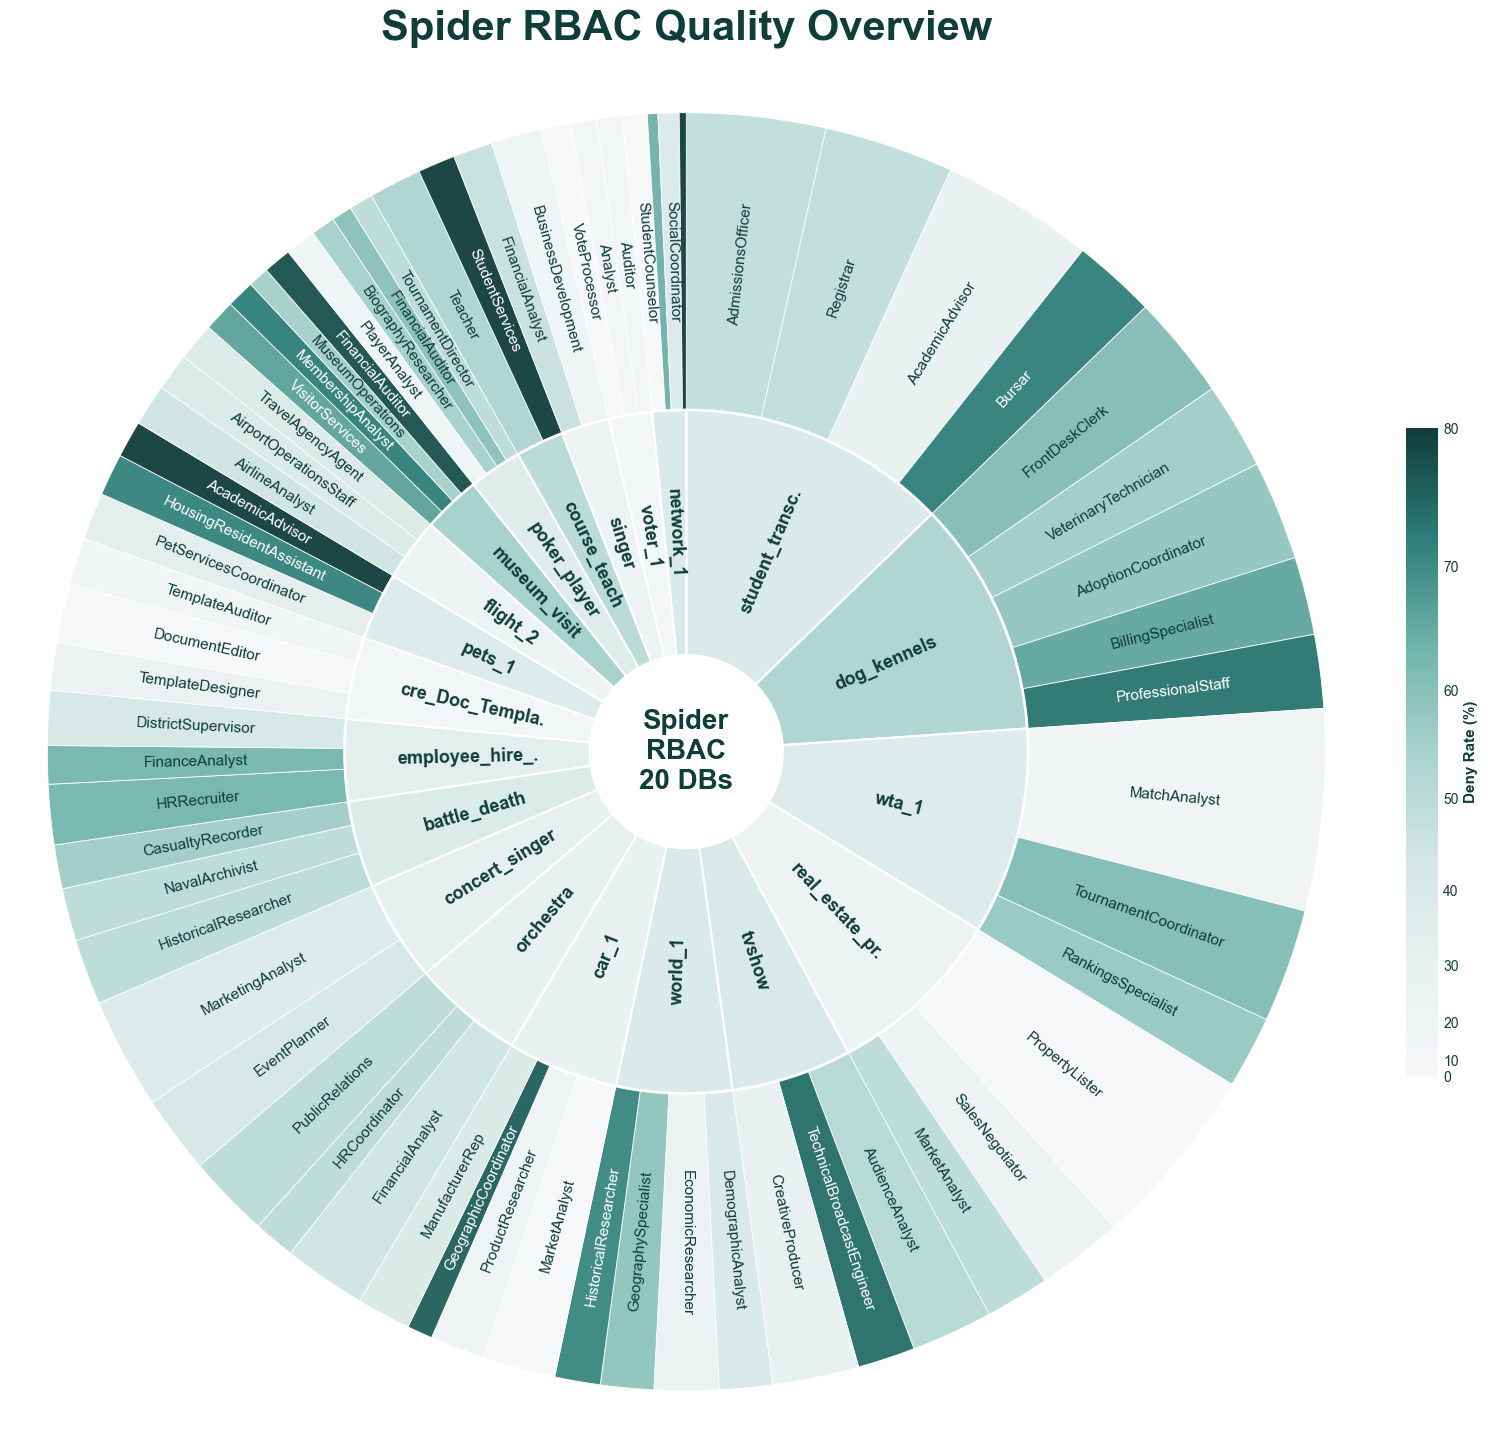

In [92]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
import numpy as np

# ==========================================
# 1. Font and Color Configuration (Configuration)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# --- [Font Control Center] ---
FONT_SIZE_TITLE  = 30  # Main title
FONT_SIZE_CENTER = 20  # Center number
FONT_SIZE_DB     = 13  # Inner ring (Database)
FONT_SIZE_ROLE   = 11  # Outer ring (Role)
FONT_SIZE_CBAR   = 11  # Legend
MIN_ANGLE_LABEL  = 2.0 # Only show text if sector angle > this (avoid overlap)

# --- Color scheme (Neutral -> Teal) ---
deny_colors = [
    "#F6F7F9",  # very light neutral
    "#E8F1F0",  # light aqua-gray
    "#D3E7E4",  # soft mint
    "#A9D2CC",  # muted teal
    "#6FB3AA",  # teal
    "#2C7C77",  # deep teal
    "#0F3D3A",  # very deep teal (accent)
]
cmap = LinearSegmentedColormap.from_list("deny_rate_teal", deny_colors)
norm = PowerNorm(gamma=1.8, vmin=0, vmax=80)

# Text color
TEXT_DARK = '#0F3D3A' 
TEXT_LIGHT = '#FFFFFF'

# ==========================================
# 2. Layout configuration
# ==========================================
CENTER_RADIUS = 0.15
INNER_WIDTH   = 0.38
GAP_WIDTH     = 0.002
OUTER_WIDTH   = 0.46

INNER_R1 = CENTER_RADIUS
INNER_R2 = INNER_R1 + INNER_WIDTH
OUTER_R1 = INNER_R2 + GAP_WIDTH
OUTER_R2 = OUTER_R1 + OUTER_WIDTH

# ==========================================
# 3. Helper functions
# ==========================================
def get_text_color(bg_color):
    """Auto contrast color"""
    r, g, b = to_rgb(bg_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return TEXT_LIGHT if luminance < 0.55 else TEXT_DARK

def get_smart_rotation(theta1, theta2):
    mid = (theta1 + theta2) / 2
    rot = mid
    norm_ang = mid % 360
    if 90 < norm_ang < 270:
        rot += 180
    return rot

def truncate_text(text, max_len=14):
    if len(text) <= max_len: return text
    return text[:max_len-1] + '.'

# ==========================================
# 4. Main plotting logic
# ==========================================
if 'db_data' not in locals():
    print("Warning: db_data missing.")
else:
    # Sort
    db_data.sort(key=lambda x: x['total_cols'], reverse=True)
    total_cols_all = sum(d['total_cols'] for d in db_data) or 1

    fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'aspect': 'equal'}) # Canvas enlarged to 15
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.axis('off')

    current_angle = 90

    for db in db_data:
        angle_span = (db['total_cols'] / total_cols_all) * 360
        if angle_span == 0: continue
        
        theta1, theta2 = current_angle - angle_span, current_angle
        
        # --- Inner ring (Database) ---
        db_rgba = cmap(norm(db['deny_rate']))
        
        wedge = Wedge(center=(0, 0), r=INNER_R2, theta1=theta1, theta2=theta2,
                      width=INNER_WIDTH, facecolor=db_rgba,
                      edgecolor='white', linewidth=1.5)
        ax.add_patch(wedge)
        
        # --- Inner ring label ---
        if angle_span > MIN_ANGLE_LABEL:
            mid = (theta1 + theta2) / 2
            label_r = INNER_R1 + (INNER_WIDTH * 0.5)
            lx = label_r * np.cos(np.radians(mid))
            ly = label_r * np.sin(np.radians(mid))
            rot = get_smart_rotation(theta1, theta2)
            font_color = get_text_color(db_rgba)
            
            # [UPGRADE] Font enlarged
            ax.text(lx, ly, truncate_text(db['db_id'], 15),
                    ha='center', va='center', rotation=rot, rotation_mode='anchor',
                    fontsize=FONT_SIZE_DB, fontweight='bold', color=font_color)

        # --- Outer ring (Roles) ---
        if db['roles']:
            total_access = sum(r['accessible'] for r in db['roles'])
            role_start = theta2 
            
            for role in db['roles']:
                if total_access > 0:
                    r_span = (role['accessible'] / total_access) * angle_span
                else:
                    r_span = angle_span / len(db['roles'])
                
                role_end = role_start - r_span
                role_rgba = cmap(norm(role['deny_rate']))
                r_font_color = get_text_color(role_rgba)
                
                r_wedge = Wedge(center=(0, 0), r=OUTER_R2, theta1=role_end, theta2=role_start,
                                width=OUTER_WIDTH, facecolor=role_rgba,
                                edgecolor='white', linewidth=0.6, alpha=0.95)
                ax.add_patch(r_wedge)
                
                # --- Outer ring label ---
                # Only show when sector is large enough
                if r_span > MIN_ANGLE_LABEL * 0.8: 
                    rmid = (role_start + role_end) / 2
                    r_label_r = OUTER_R1 + (OUTER_WIDTH * 0.5)
                    rx = r_label_r * np.cos(np.radians(rmid))
                    ry = r_label_r * np.sin(np.radians(rmid))
                    r_rot = get_smart_rotation(role_end, role_start)
                    
                    # [UPGRADE] Font enlarged
                    ax.text(rx, ry, role['role'],
                            ha='center', va='center', rotation=r_rot, rotation_mode='anchor',
                            fontsize=FONT_SIZE_ROLE, fontweight='medium', color=r_font_color)
                
                role_start = role_end

        current_angle -= angle_span

    # ==========================================
    # 5. Decoration details (all enlarged)
    # ==========================================
    
    # Center
    center_text = f"Spider\nRBAC\n{len(db_data)} DBs"
    ax.text(0, 0, center_text, ha='center', va='center', 
            fontsize=FONT_SIZE_CENTER, fontweight='heavy', color=TEXT_DARK)

    # Title
    ax.set_title('Spider RBAC Quality Overview', 
                 fontsize=FONT_SIZE_TITLE, fontweight='bold', y=1.02, color=TEXT_DARK)

    # Legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.03, shrink=0.45)
    cbar.set_label('Deny Rate (%)', fontsize=FONT_SIZE_CBAR, weight='bold', color=TEXT_DARK)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=TEXT_DARK, labelcolor=TEXT_DARK, labelsize=FONT_SIZE_CBAR-1, length=0)

    plt.tight_layout()
    plt.show()

## 8. Notes

### Workflow
1. Section 3: Generate initial column-level roles
2. Section 4: Validate against database schemas
3. Section 5: Quality assessment (Deny Rate, Similarity, Overlap)
4. Section 6: Human-in-the-loop regeneration
5. Section 7: Preview and export

### Quality Thresholds
| Metric | Range | Description |
|--------|-------|-------------|
| Deny Rate | 5-90% | Columns NOT accessible |
| Semantic Similarity | >0.6 | Description matches policy |
| Policy Overlap | <70% | Role differentiation |

### Outputs
- `outputs/spider_column_level_rbac_assignments_v2.json`
- `outputs/column_level_rbac_dataset_spider_YYYYMMDD.json`